In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path
import kaleido

sns.set_style("whitegrid")

DATA = Path("../data/processed")

In [3]:
fund_df = pd.read_csv(DATA / "clean_01_fund_master.csv")

nav_df = pd.read_csv(DATA / "clean_nav.csv")

aum_df = pd.read_csv(DATA / "clean_03_aum_by_fund_house.csv")

sip_df = pd.read_csv(DATA / "clean_04_monthly_sip_inflows.csv")

category_df = pd.read_csv(DATA / "clean_05_category_inflows.csv")

folio_df = pd.read_csv(DATA / "clean_06_industry_folio_count.csv")

performance_df = pd.read_csv(DATA / "clean_performance.csv")

transactions_df = pd.read_csv(DATA / "clean_transactions.csv")

portfolio_df = pd.read_csv(DATA / "clean_09_portfolio_holdings.csv")

benchmark_df = pd.read_csv(DATA / "clean_10_benchmark_indices.csv")

In [4]:
datasets = {
    "Fund Master": fund_df,
    "NAV": nav_df,
    "AUM": aum_df,
    "SIP": sip_df,
    "Category": category_df,
    "Folio": folio_df,
    "Performance": performance_df,
    "Transactions": transactions_df,
    "Portfolio": portfolio_df,
    "Benchmark": benchmark_df
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 21)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [30]:
charts_dir = Path("../reports/charts")

charts_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Charts folder ready")

Charts folder ready


# Individual Scheme NAV Trend Analysis

### Objective
Analyze NAV movement for each mutual fund scheme from 2022–2026.

### Business Questions
- Which schemes delivered the strongest NAV growth?
- Which schemes showed higher volatility?
- Were there visible correction phases during 2024?
- Which funds recovered fastest after corrections?

### Expected Insight
Understand long-term performance and trend behavior for every mutual fund scheme individually.


SCHEME: SBI Bluechip Fund - Regular Plan - Growth


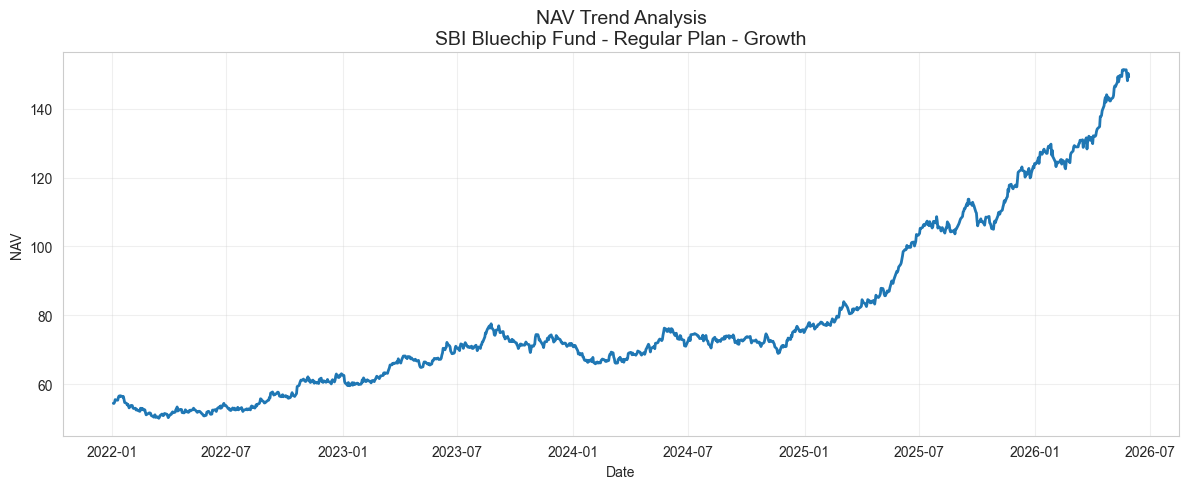


SCHEME: SBI Bluechip Fund - Direct Plan - Growth


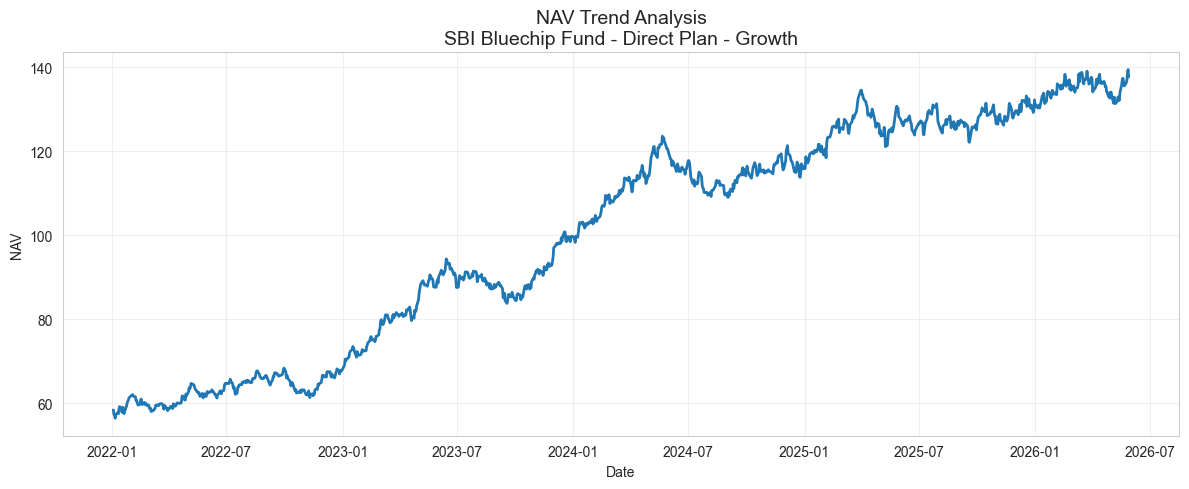


SCHEME: SBI Small Cap Fund - Regular Plan - Growth


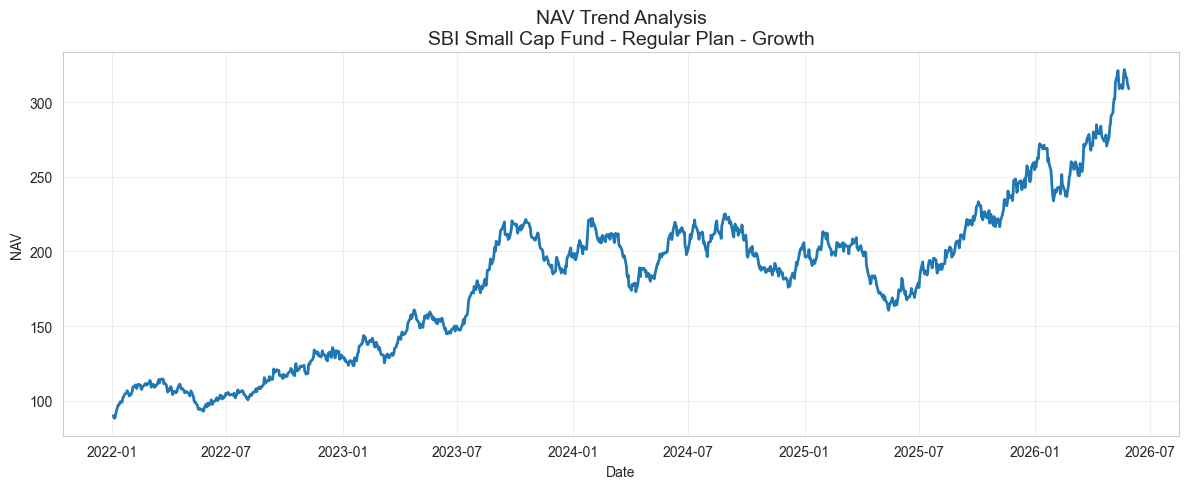


SCHEME: SBI Small Cap Fund - Direct Plan - Growth


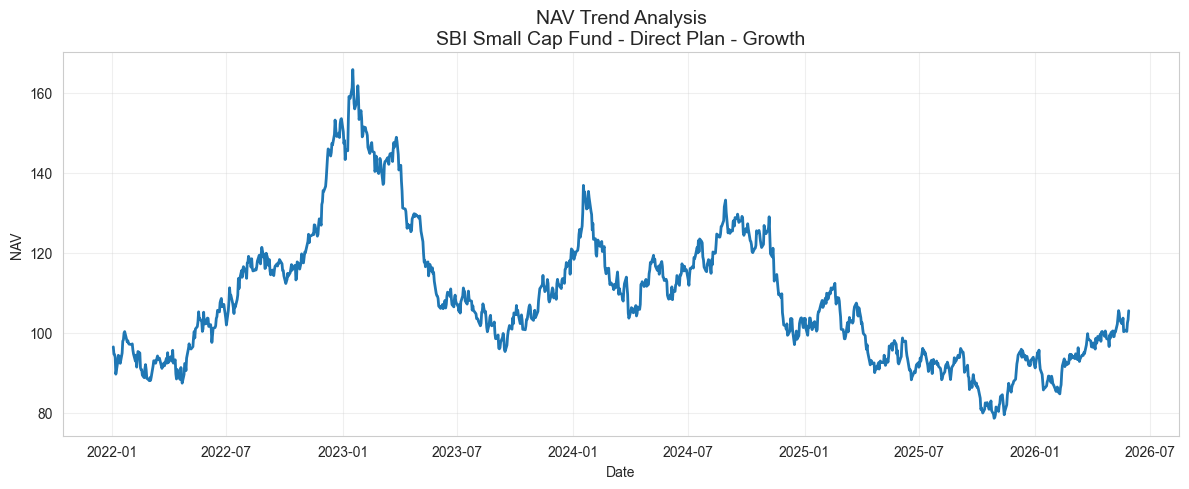


SCHEME: SBI Magnum Gilt Fund - Regular Plan - Growth


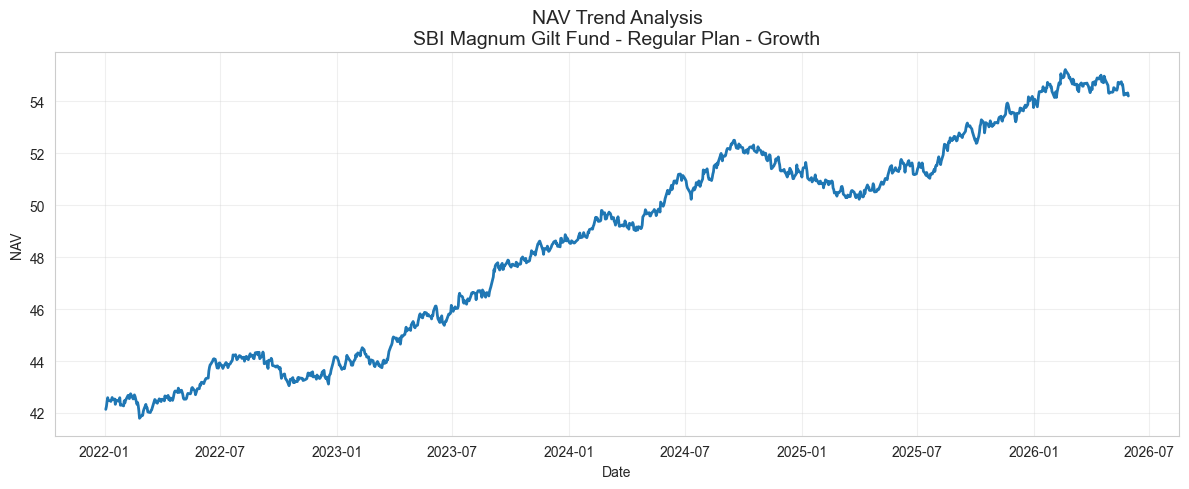


SCHEME: HDFC Top 100 Fund - Regular Plan - Growth


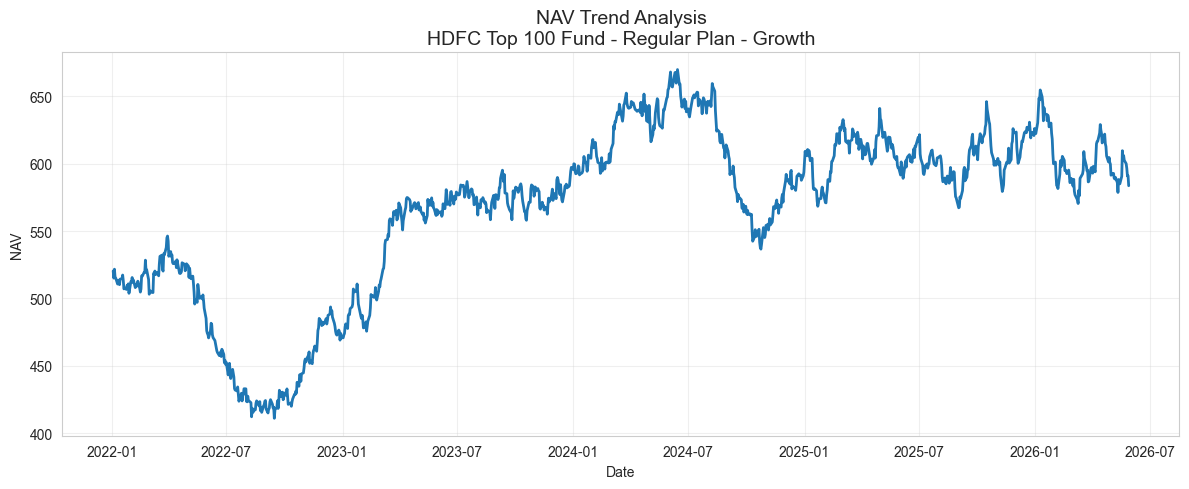


SCHEME: HDFC Top 100 Fund - Direct Plan - Growth


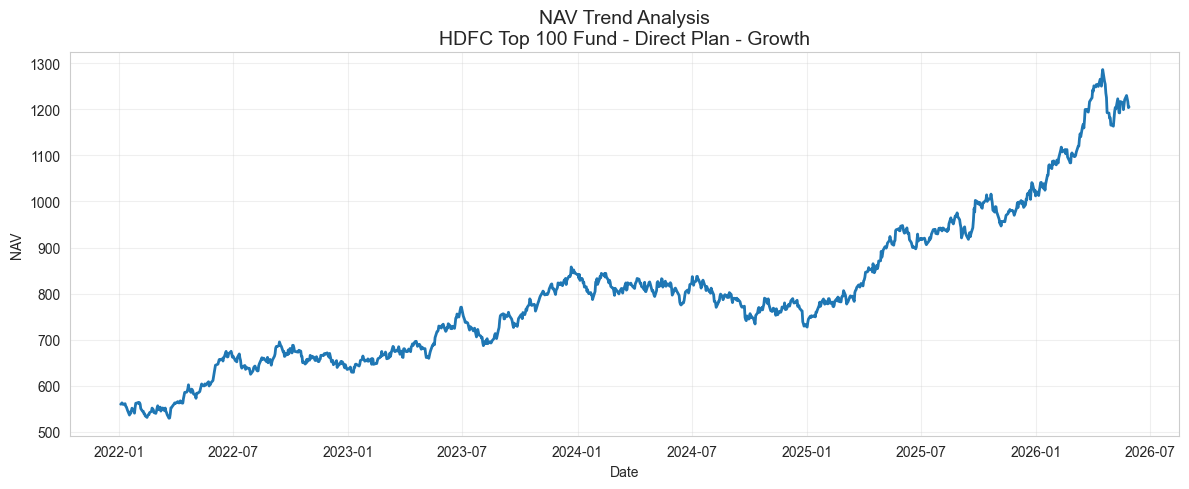


SCHEME: HDFC Mid-Cap Opportunities Fund - Regular - Growth


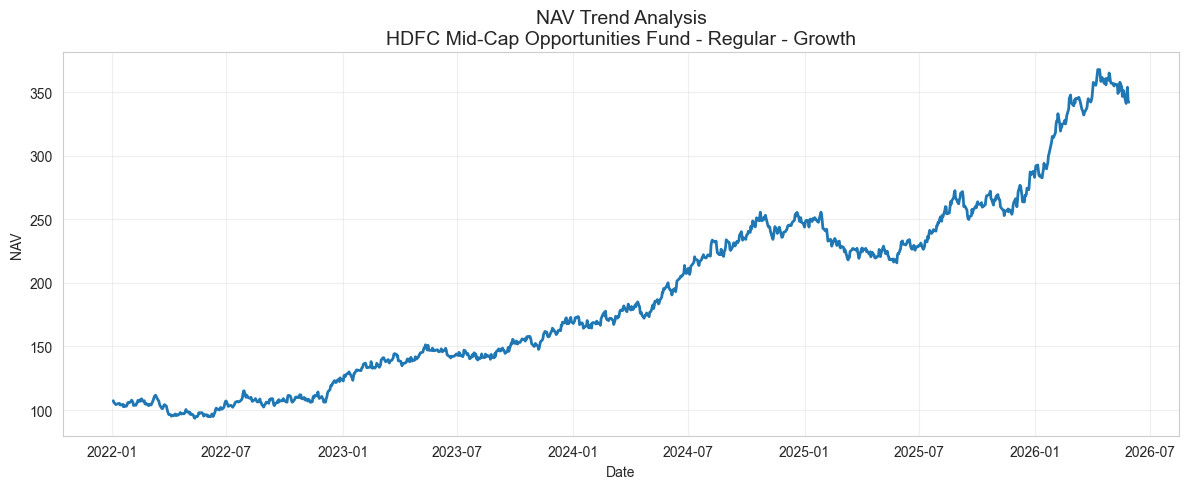


SCHEME: HDFC Mid-Cap Opportunities Fund - Direct - Growth


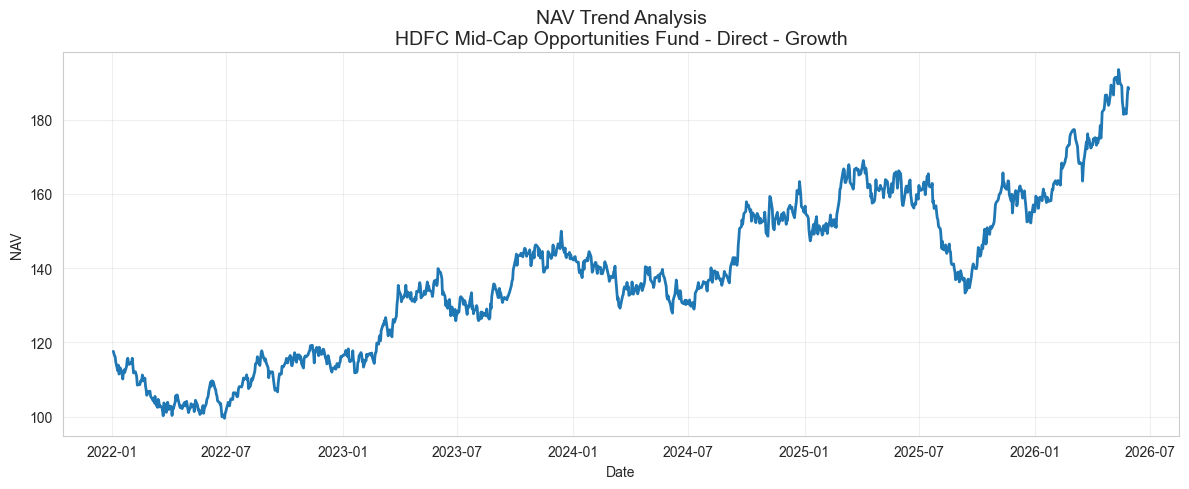


SCHEME: HDFC Short Term Debt Fund - Regular - Growth


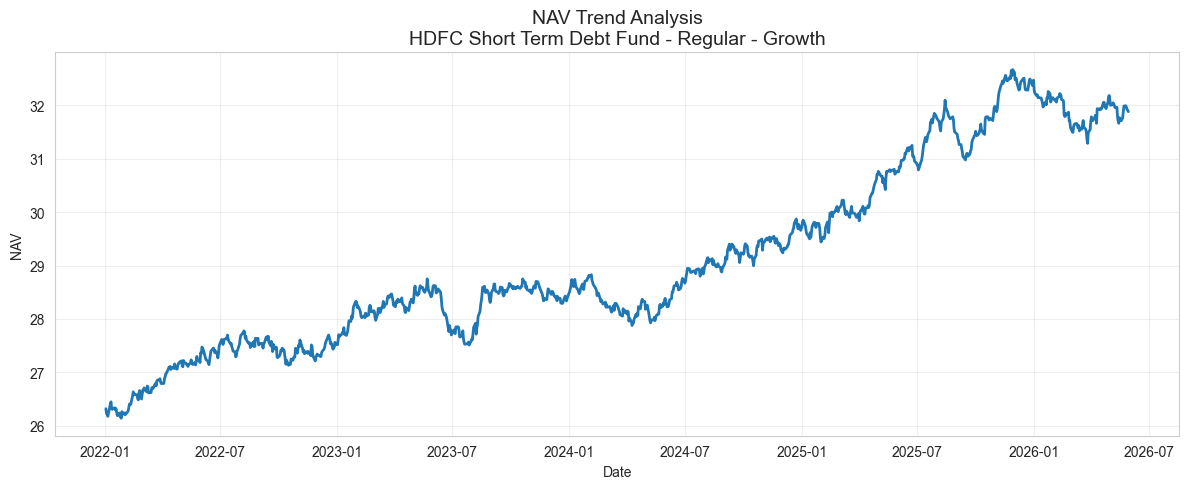


SCHEME: ICICI Pru Bluechip Fund - Regular - Growth


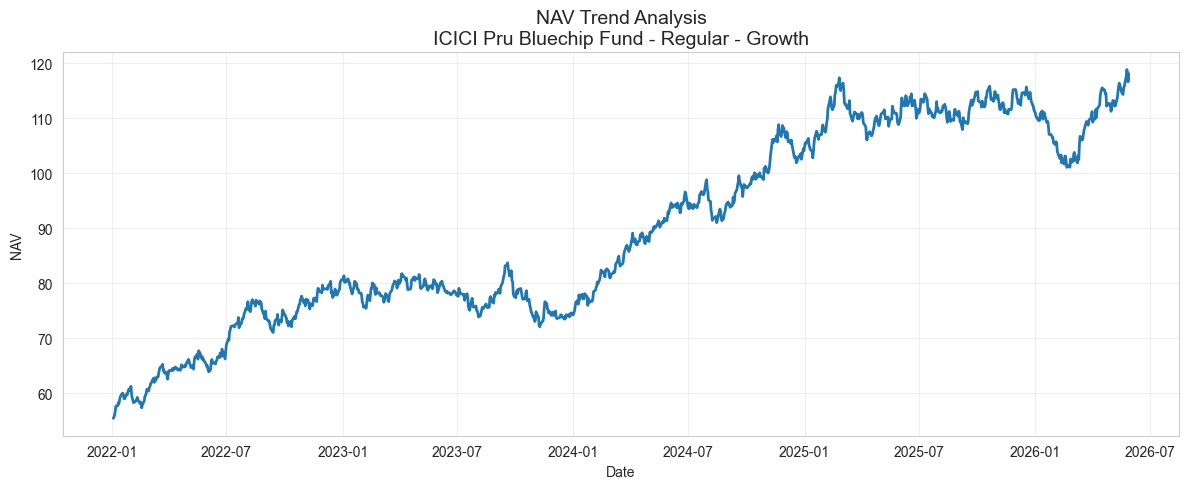


SCHEME: ICICI Pru Bluechip Fund - Direct - Growth


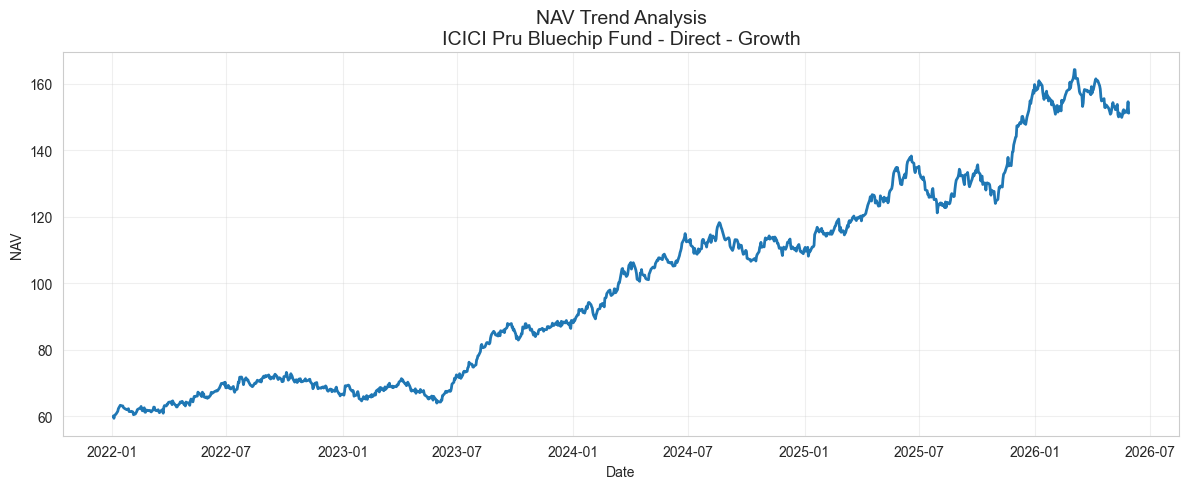


SCHEME: ICICI Pru Midcap Fund - Regular - Growth


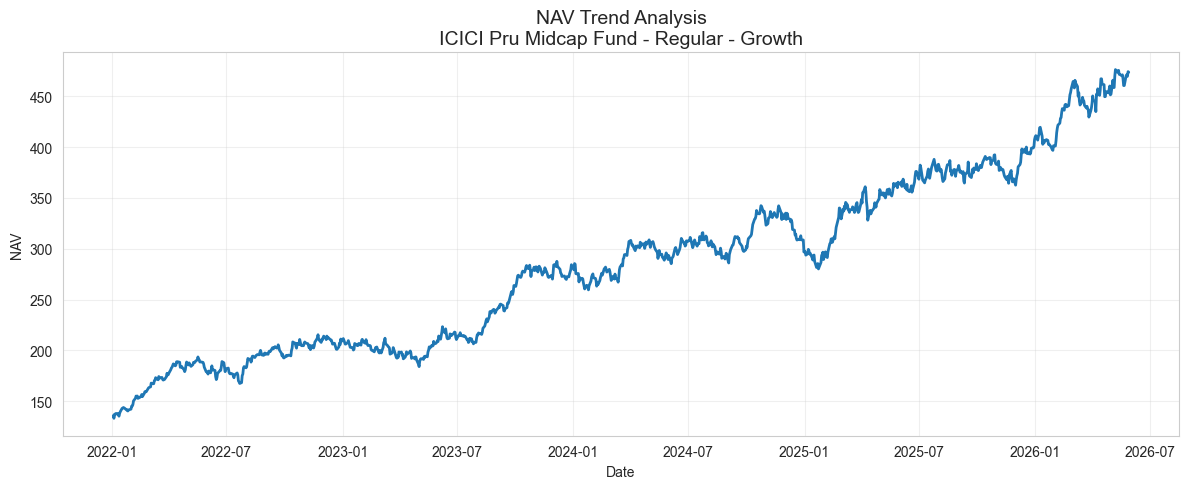


SCHEME: ICICI Pru Value Discovery Fund - Regular - Growth


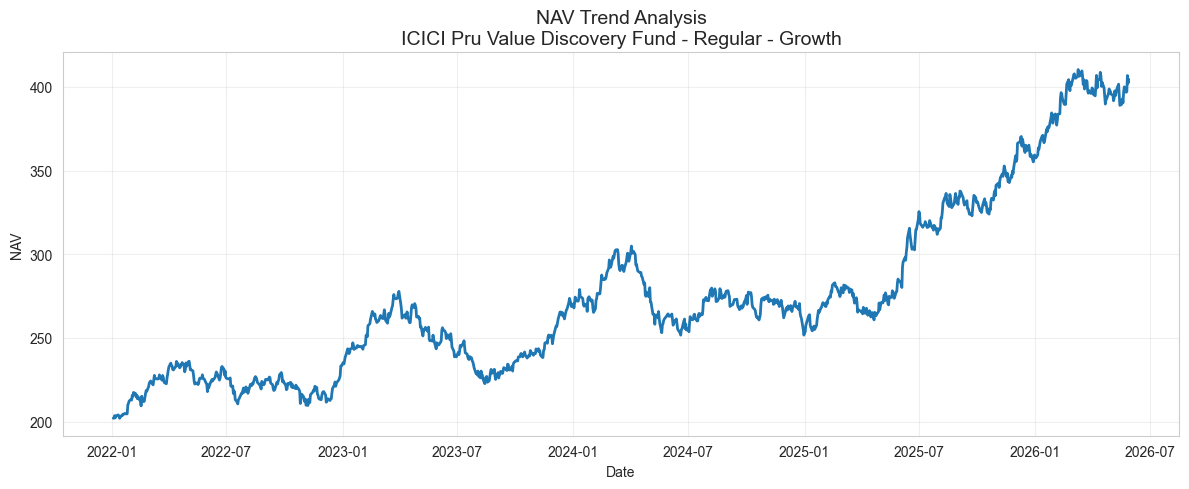


SCHEME: ICICI Pru Liquid Fund - Regular - Growth


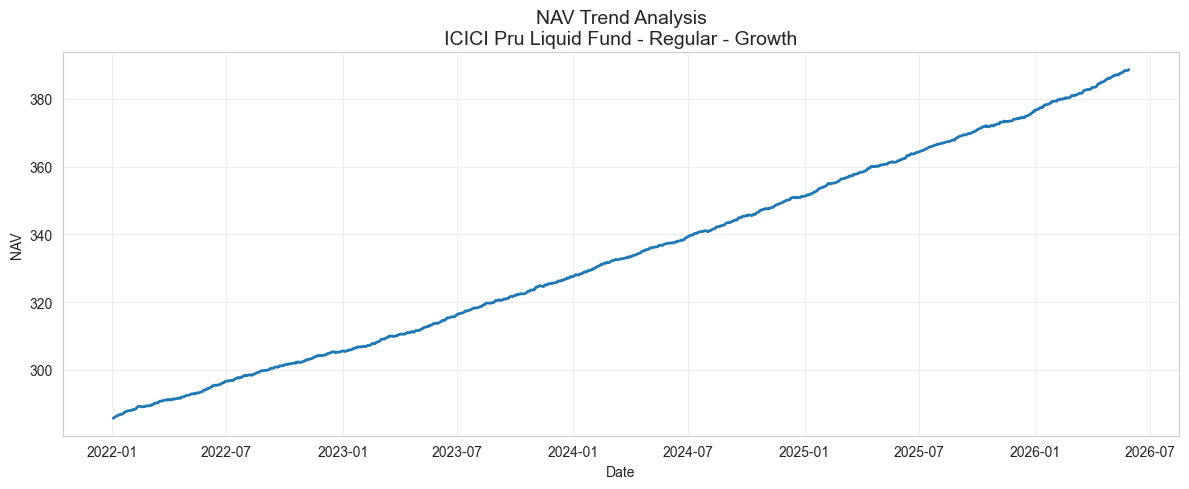


SCHEME: Nippon India Large Cap Fund - Regular - Growth


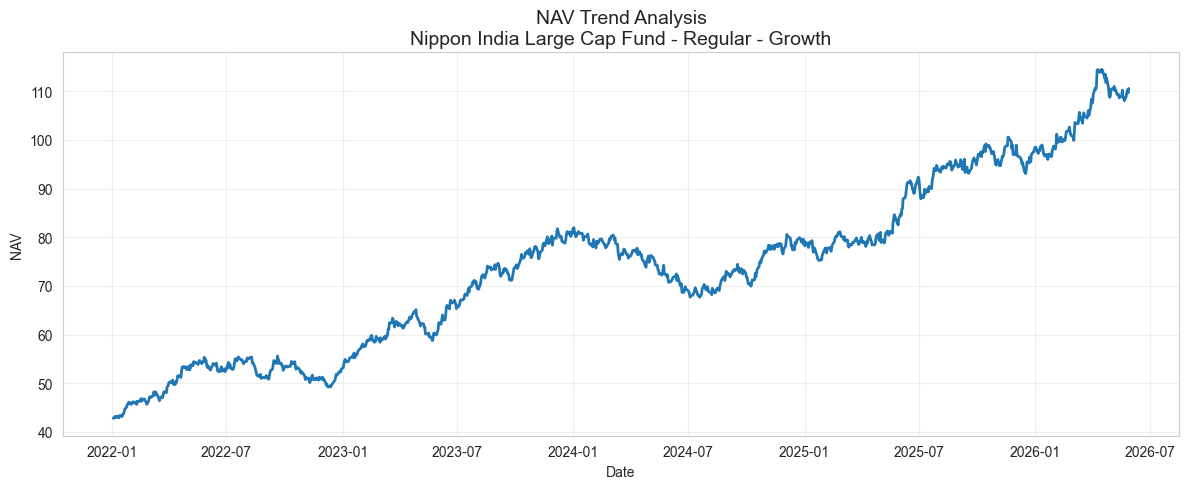


SCHEME: Nippon India Large Cap Fund - Direct - Growth


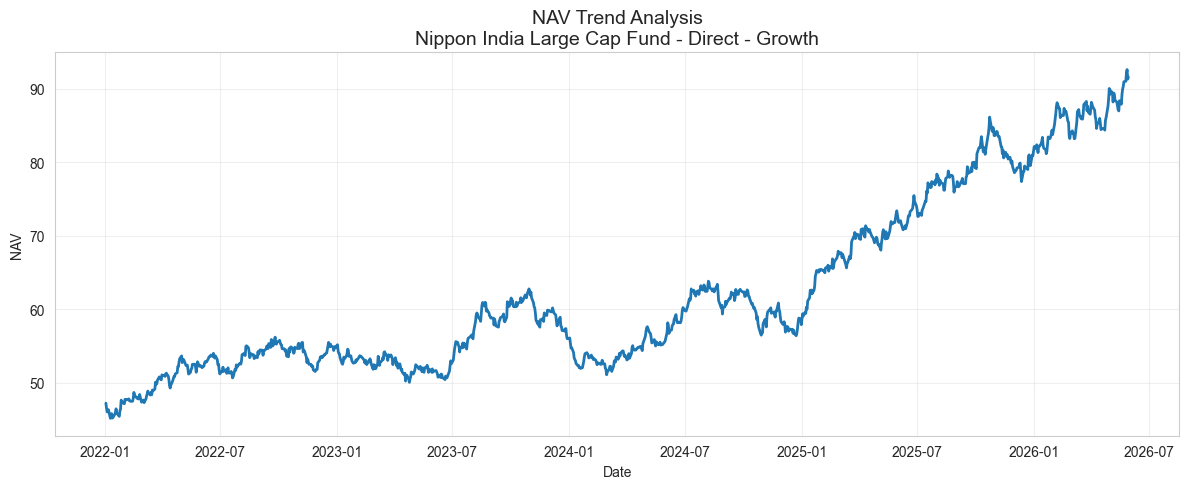


SCHEME: Nippon India Small Cap Fund - Regular - Growth


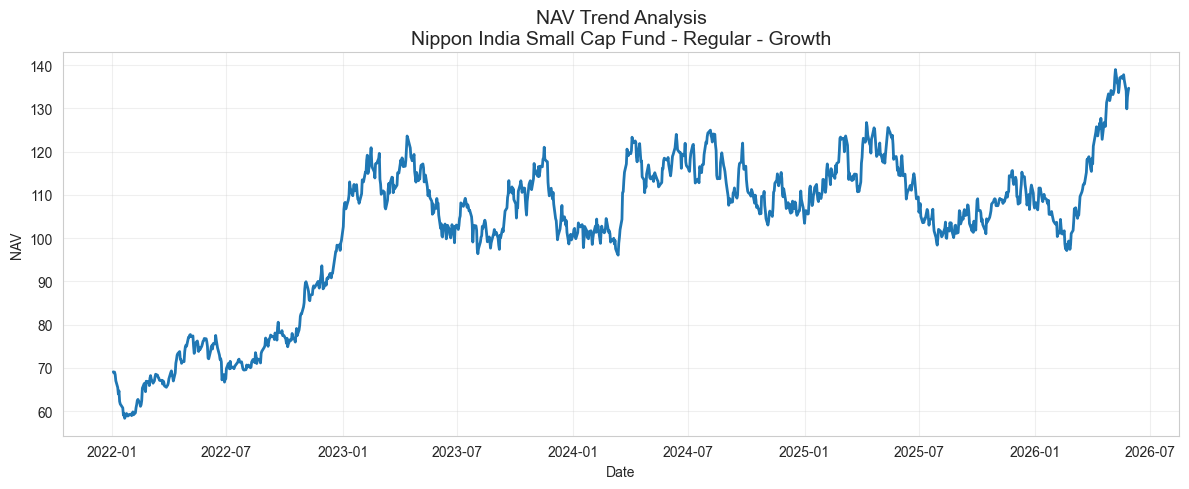


SCHEME: Nippon India ETF Nifty 50 BeES


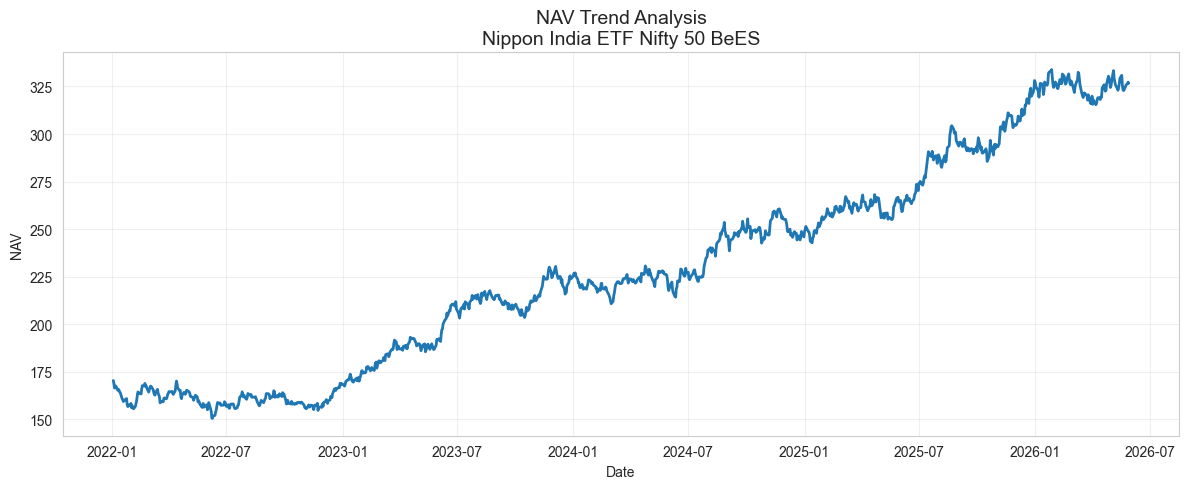


SCHEME: Nippon India Gilt Securities Fund - Regular - Growth


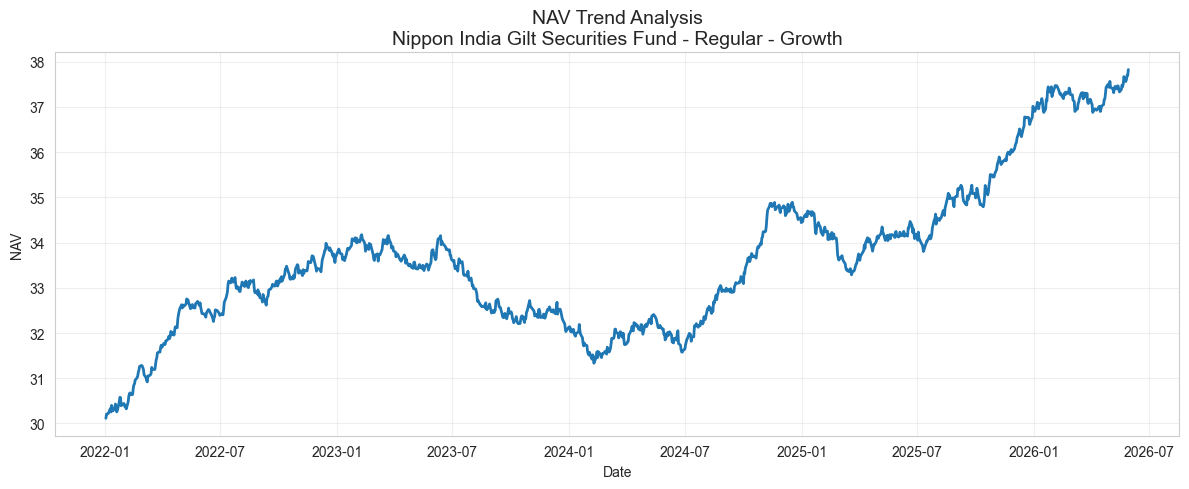


SCHEME: Kotak Bluechip Fund - Regular - Growth


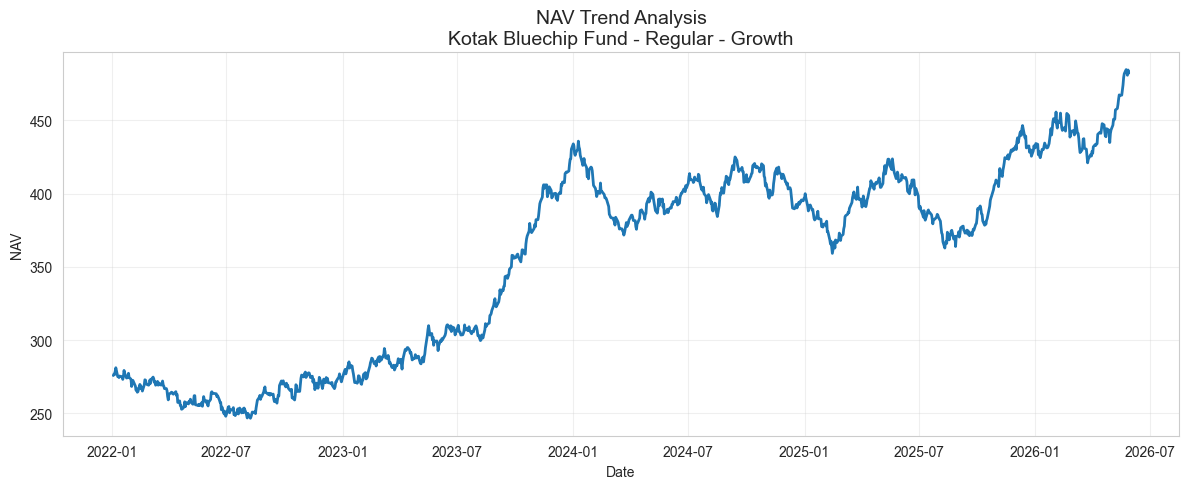


SCHEME: Kotak Emerging Equity Fund - Regular - Growth


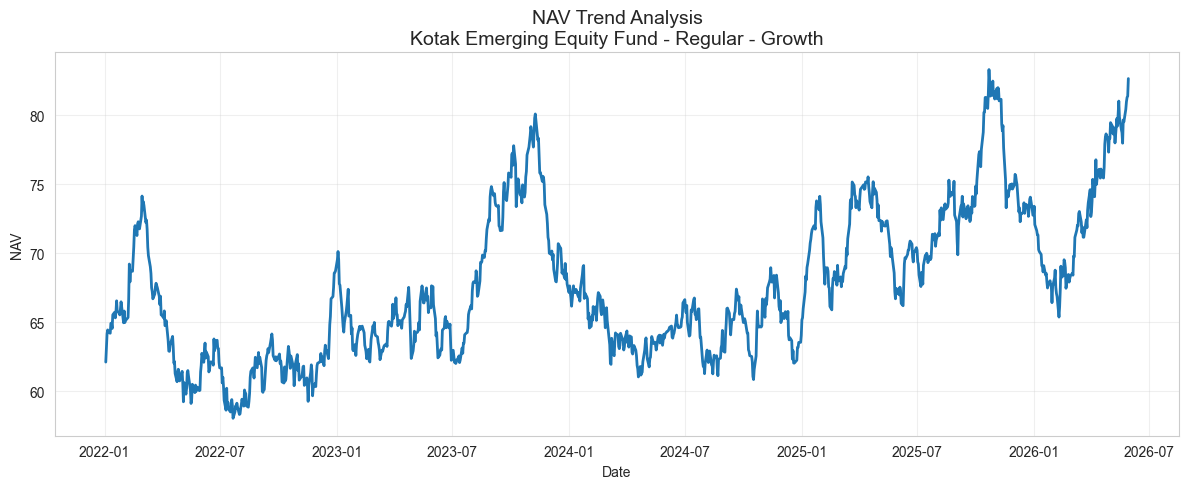


SCHEME: Kotak Flexicap Fund - Regular - Growth


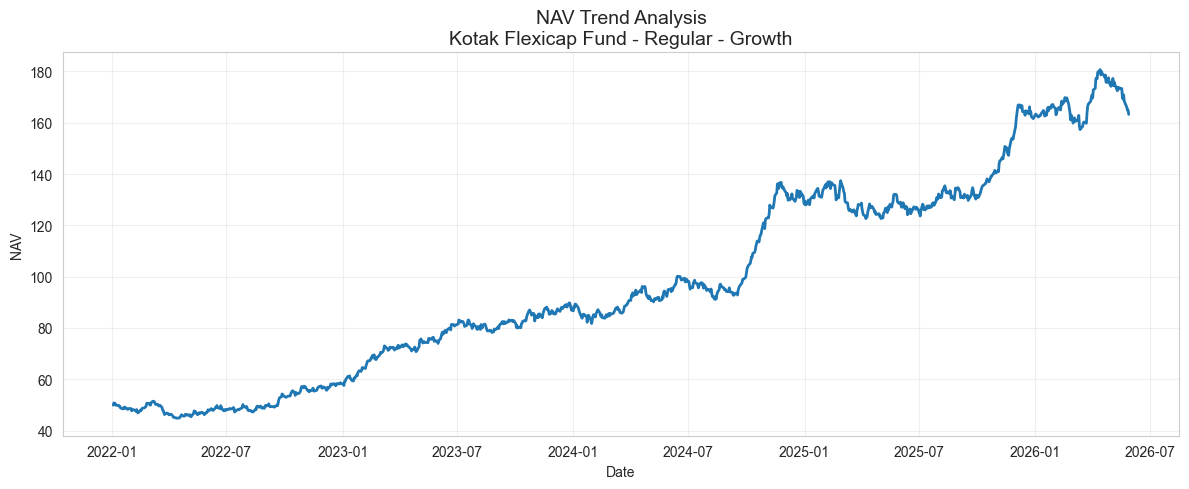


SCHEME: Kotak Liquid Fund - Regular - Growth


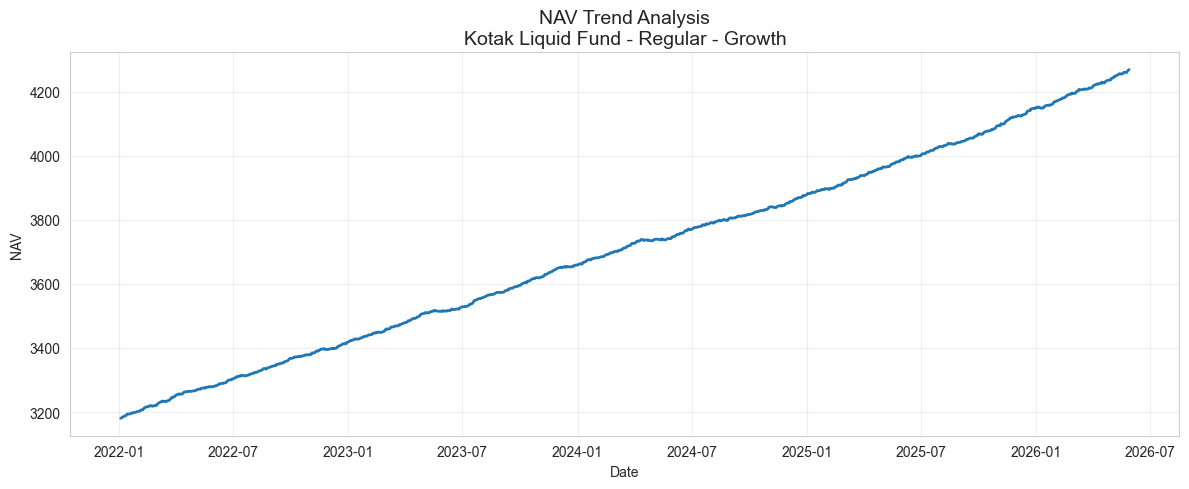


SCHEME: Axis Bluechip Fund - Regular - Growth


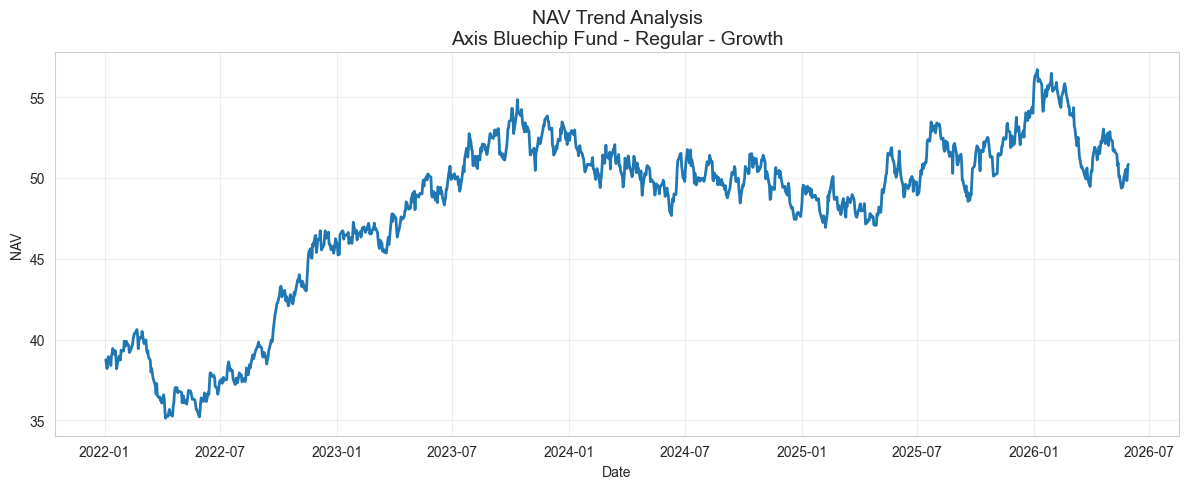


SCHEME: Axis Bluechip Fund - Direct - Growth


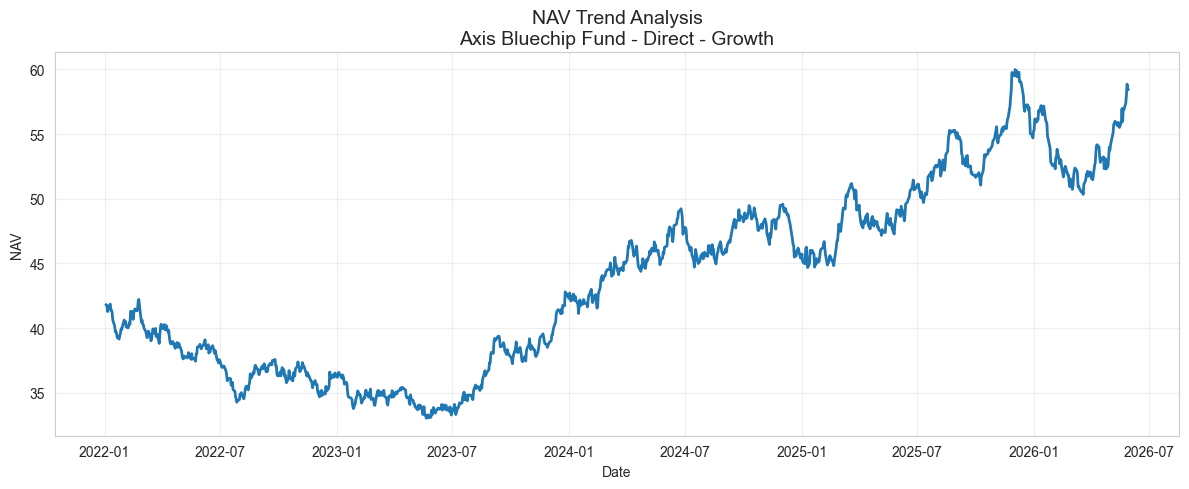


SCHEME: Axis Midcap Fund - Regular - Growth


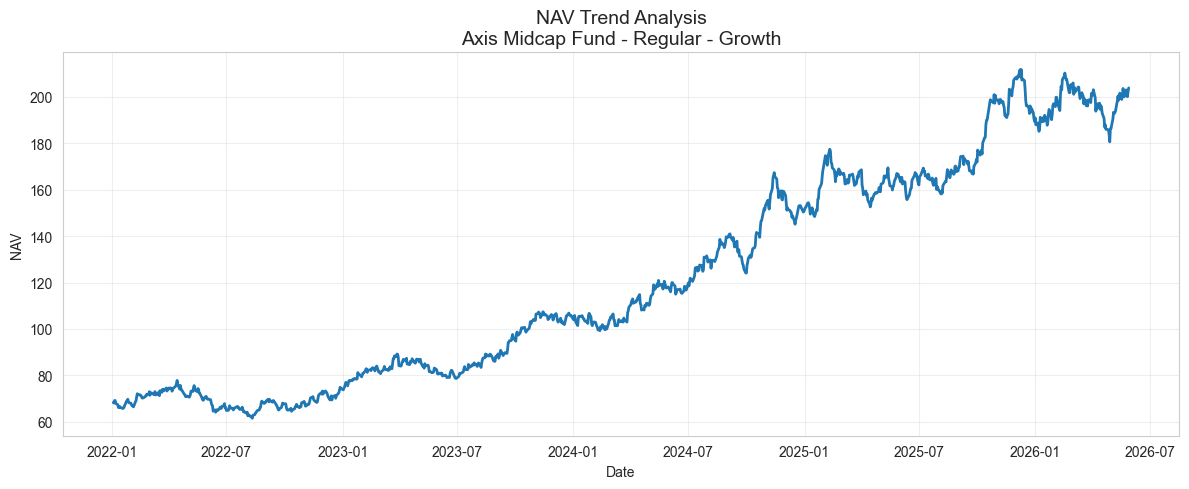


SCHEME: Axis Small Cap Fund - Regular - Growth


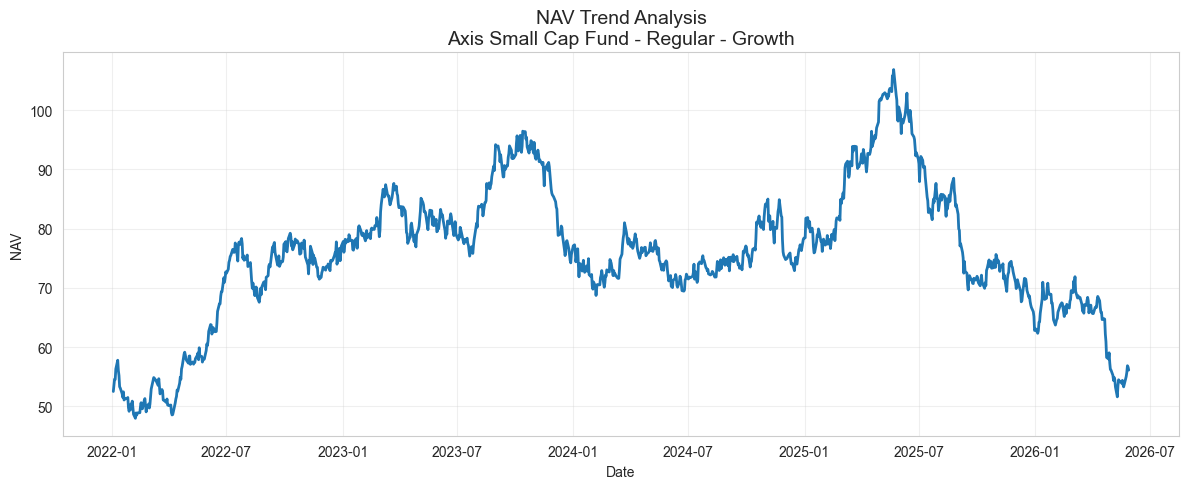


SCHEME: ABSL Frontline Equity Fund - Regular - Growth


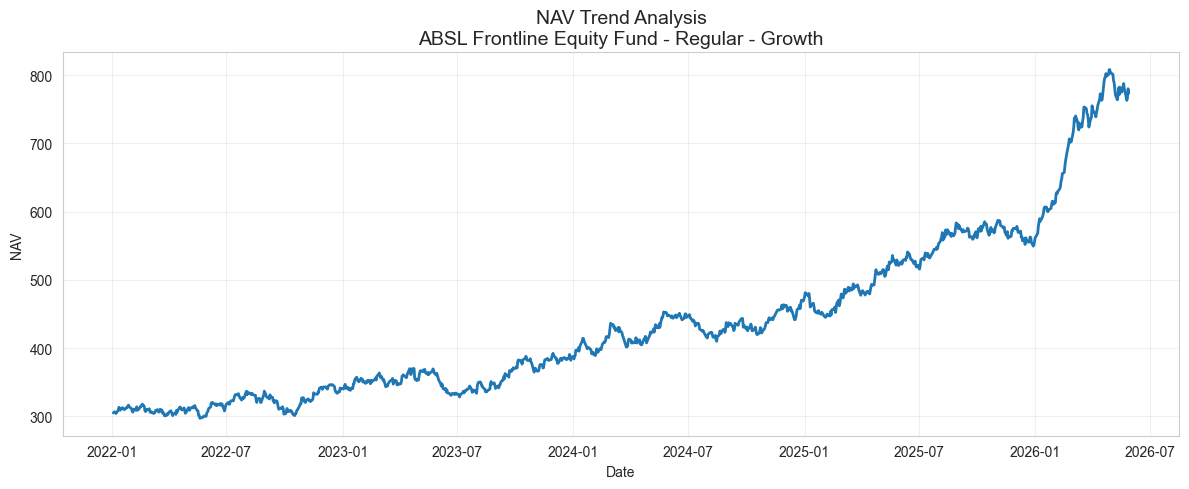


SCHEME: ABSL Small Cap Fund - Regular - Growth


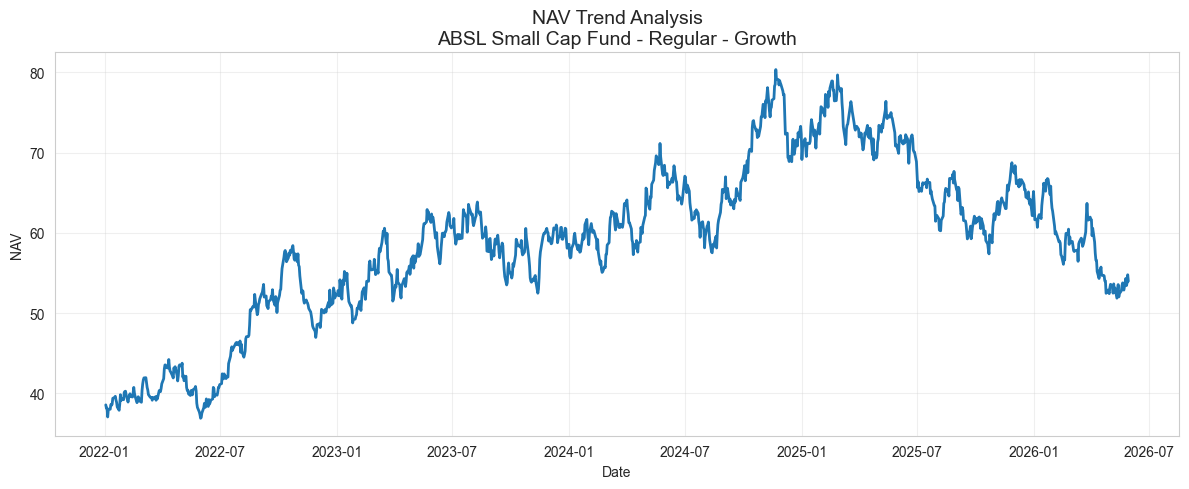


SCHEME: ABSL Liquid Fund - Regular - Growth


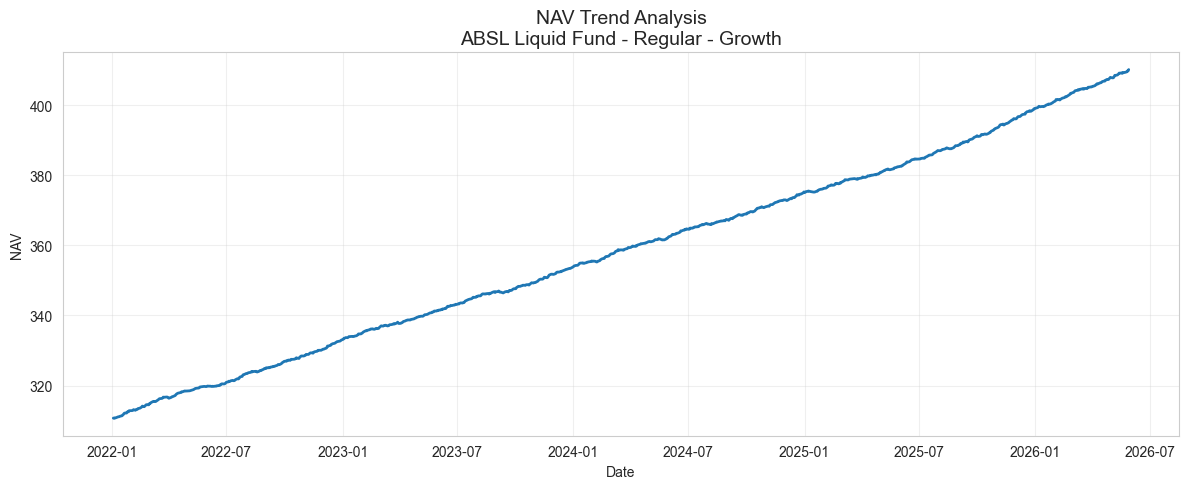


SCHEME: UTI Nifty 50 Index Fund - Regular - Growth


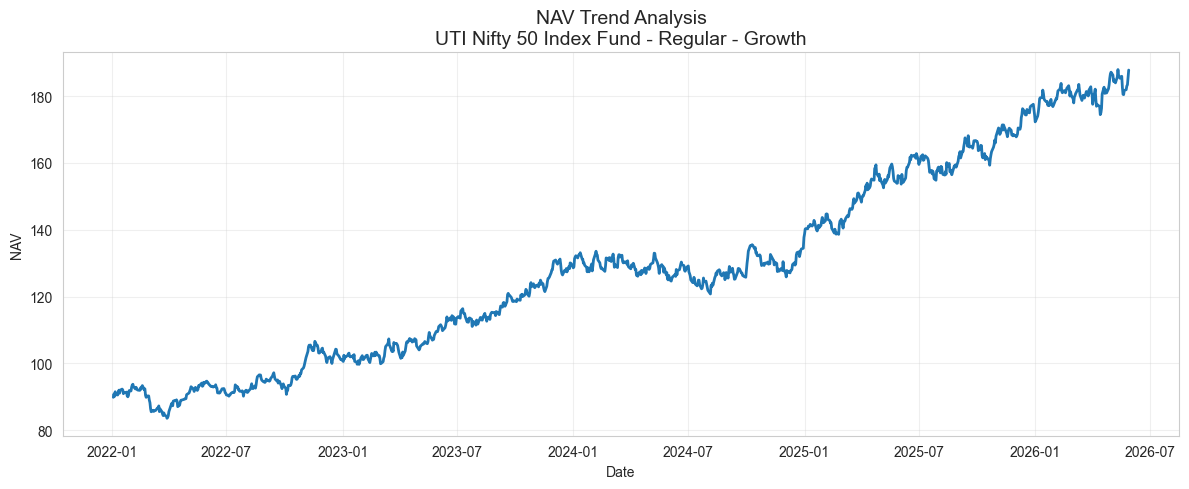


SCHEME: UTI Mid Cap Fund - Regular - Growth


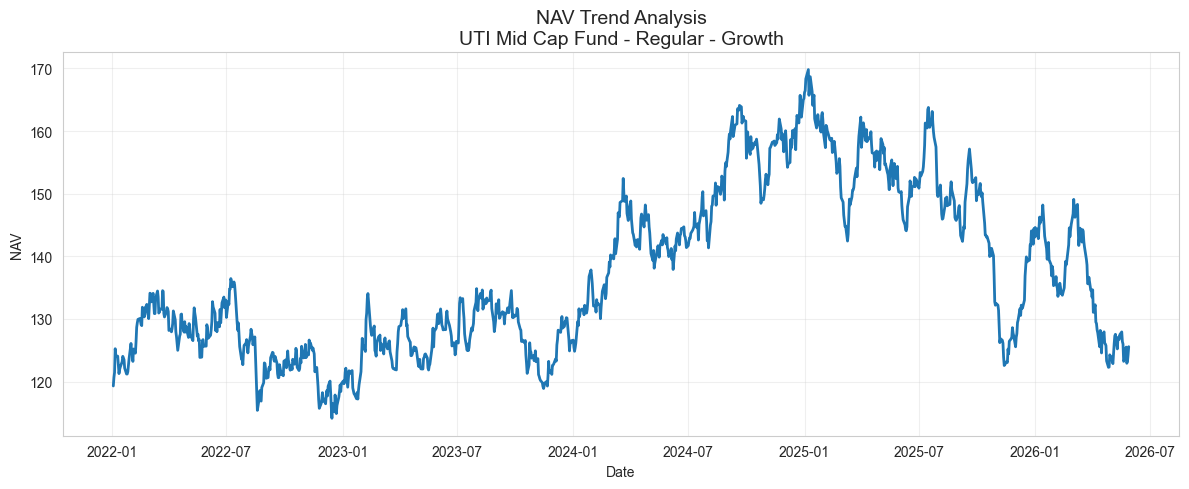


SCHEME: UTI Flexi Cap Fund - Regular - Growth


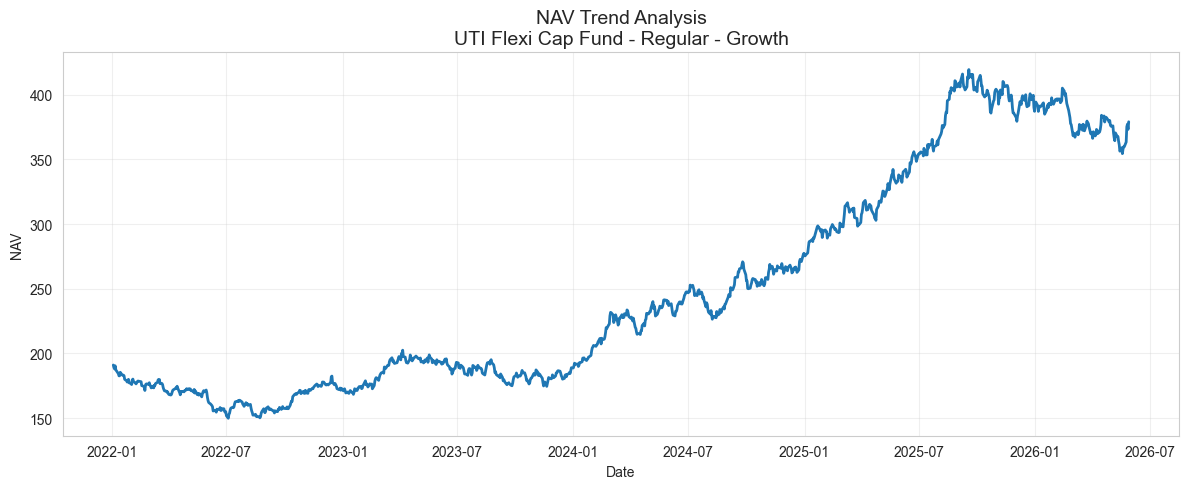


SCHEME: Mirae Asset Large Cap Fund - Regular - Growth


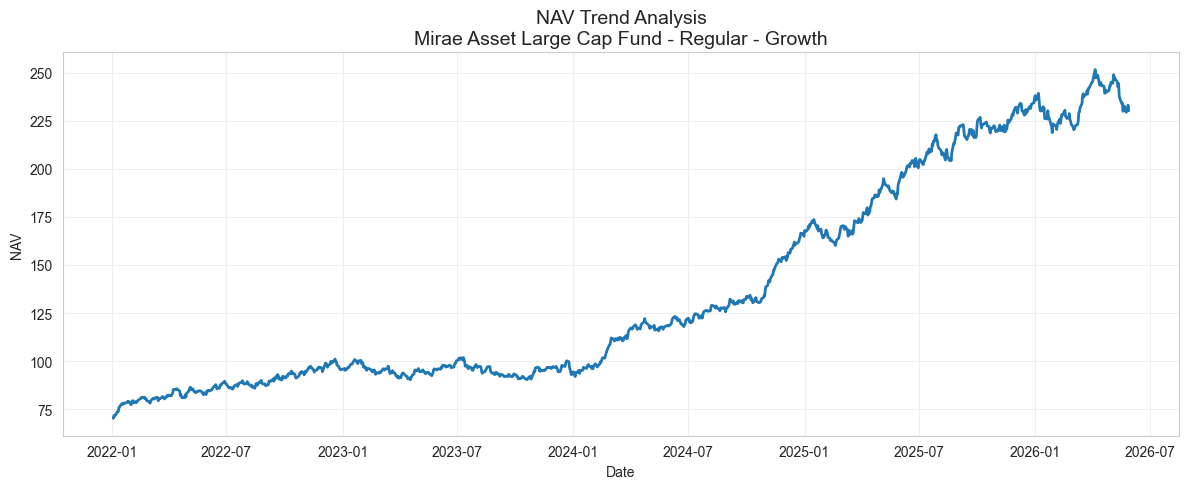


SCHEME: Mirae Asset Emerging Bluechip Fund - Regular - Growth


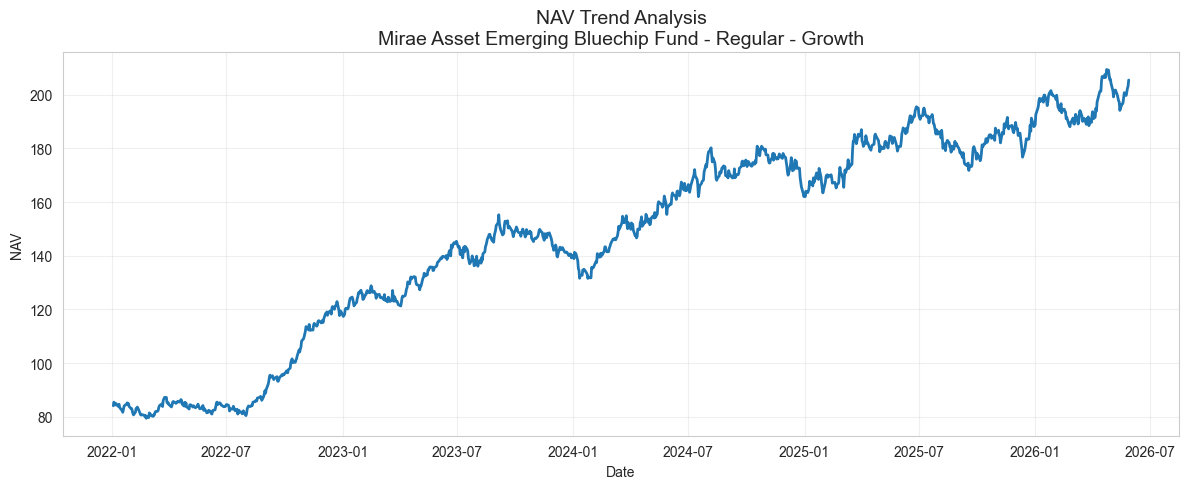


SCHEME: Mirae Asset Tax Saver Fund - Regular - Growth


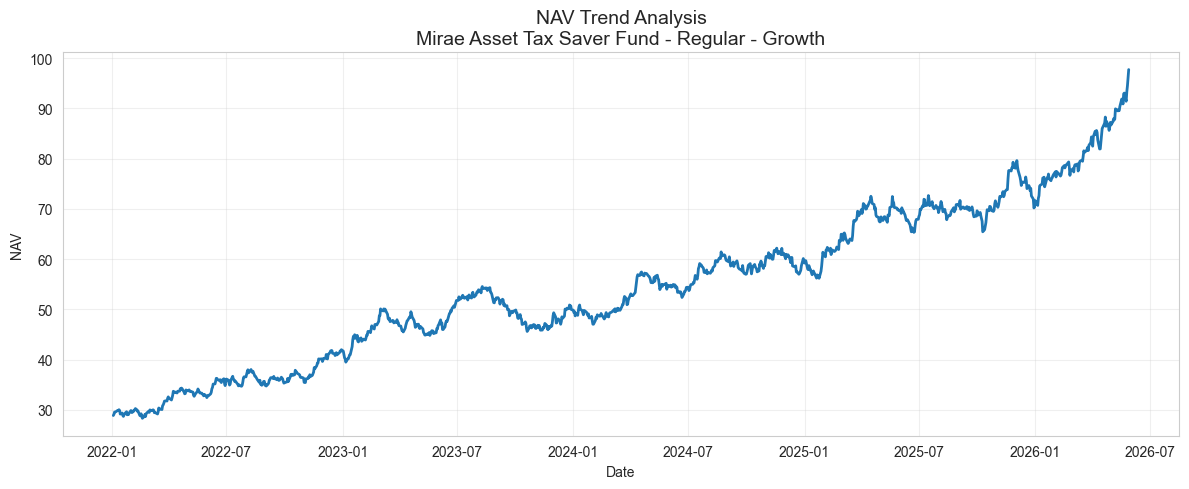


SCHEME: DSP Top 100 Equity Fund - Regular - Growth


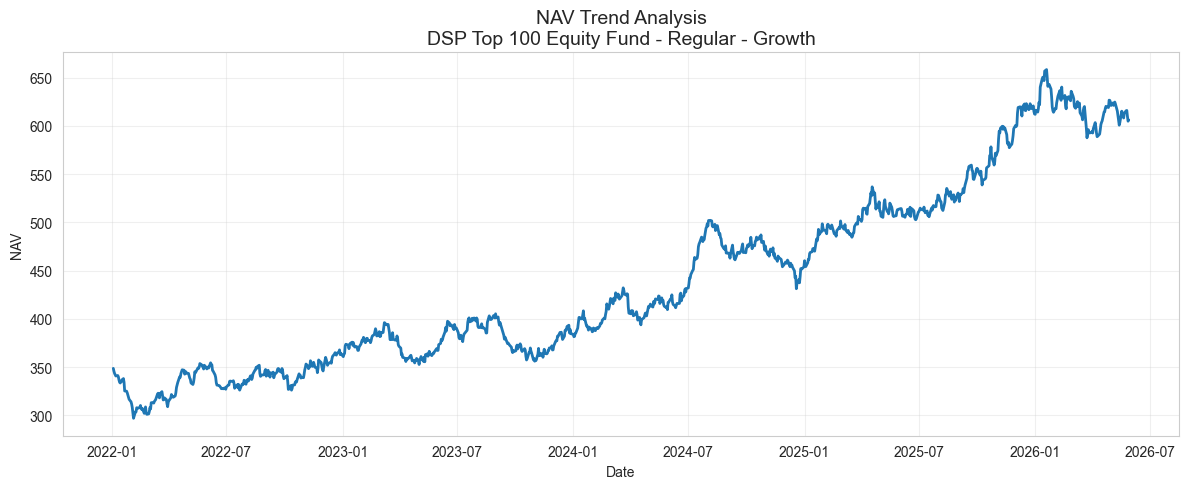


SCHEME: DSP Midcap Fund - Regular - Growth


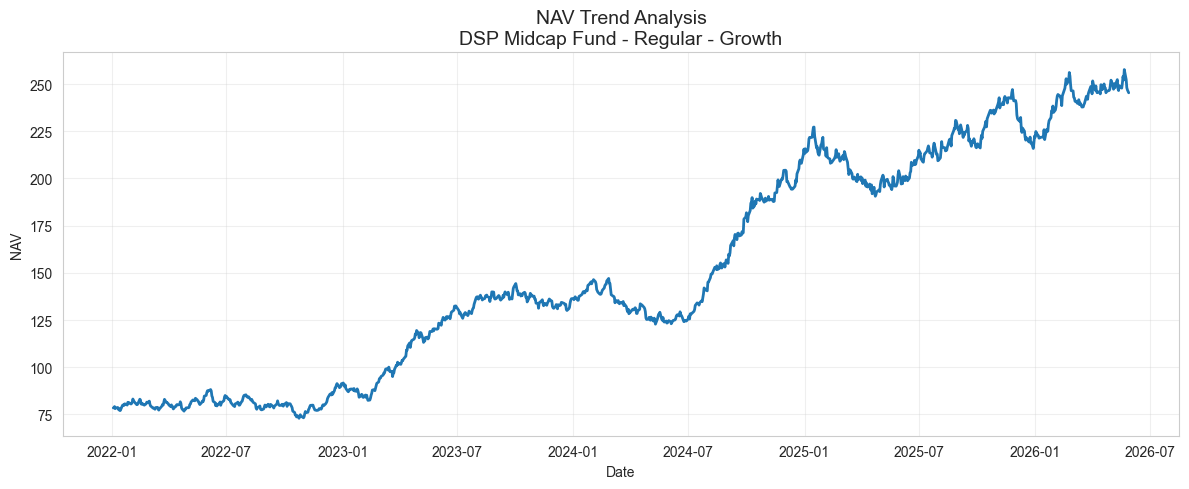


SCHEME: DSP Small Cap Fund - Regular - Growth


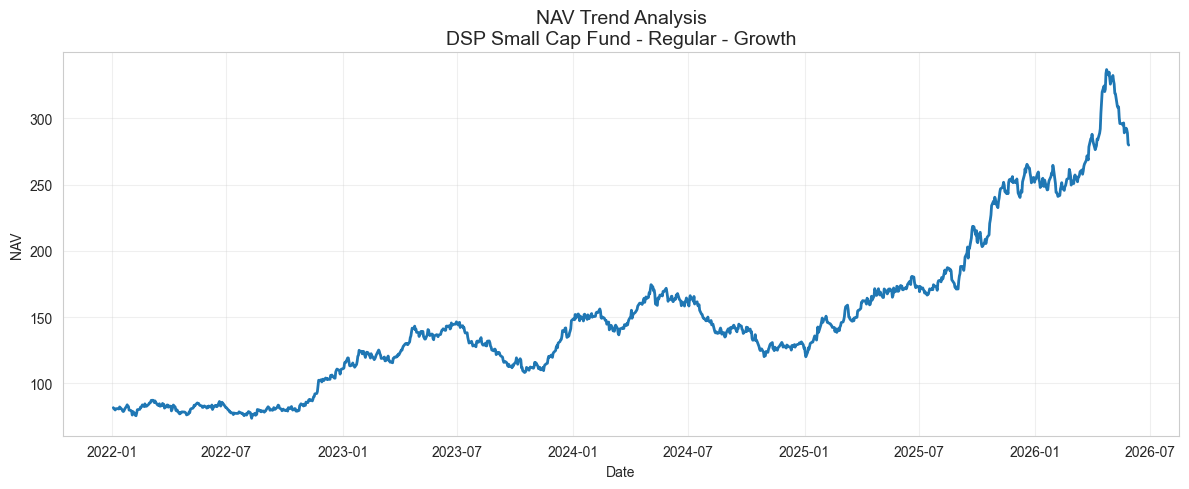


All charts displayed and exported successfully.


In [31]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create charts folder
charts_dir = Path("../reports/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

# Convert date column
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Mapping AMFI -> Scheme Name
scheme_map = fund_df[
    ["amfi_code", "scheme_name"]
].drop_duplicates()

for _, row in scheme_map.iterrows():

    amfi_code = row["amfi_code"]
    scheme_name = row["scheme_name"]

    scheme_nav = (
        nav_df[nav_df["amfi_code"] == amfi_code]
        .sort_values("date")
    )

    # Markdown-like heading in notebook output
    print("\n" + "="*100)
    print(f"SCHEME: {scheme_name}")
    print("="*100)

    plt.figure(figsize=(12,5))

    plt.plot(
        scheme_nav["date"],
        scheme_nav["nav"],
        linewidth=2
    )

    plt.title(
        f"NAV Trend Analysis\n{scheme_name}",
        fontsize=14
    )

    plt.xlabel("Date")
    plt.ylabel("NAV")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save chart
    safe_name = (
        scheme_name
        .replace("/", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        charts_dir / f"{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show chart in notebook
    plt.show()

    plt.close()

print("\nAll charts displayed and exported successfully.")

In [35]:
aum_df["fund_house"].nunique()

10

In [36]:
aum_df["fund_house"].unique()

<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str

# Chart 2: AUM by Fund House (2022–2025)

Grouped bar chart comparing Assets Under Management (AUM) across major mutual fund houses.

Objective:
- Compare AMC size across years
- Identify industry leaders
- Highlight SBI Mutual Fund's dominance with ₹12.5 Lakh Crore AUM in 2025

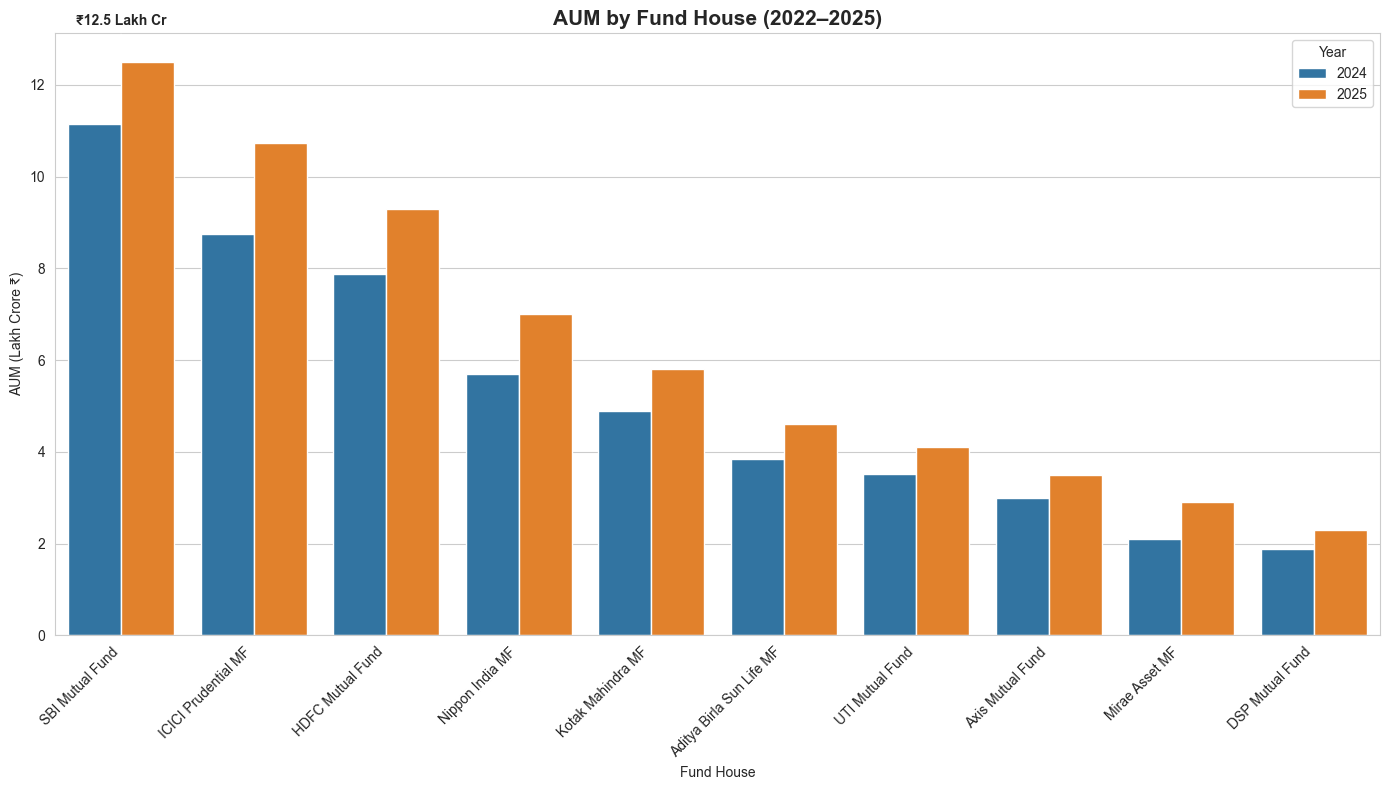

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only year-end (December) observations
aum_year = aum_df[aum_df["date"].dt.month == 12].copy()

aum_year["year"] = aum_year["date"].dt.year.astype(str)

# Sort by latest AUM for cleaner chart
latest_order = (
    aum_year[aum_year["year"] == "2025"]
    .sort_values("aum_lakh_crore", ascending=False)
    ["fund_house"]
)

plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=aum_year,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    order=latest_order
)

plt.title(
    "AUM by Fund House (2022–2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=45, ha="right")

# Highlight SBI 2025
sbi_2025 = aum_year[
    (aum_year["fund_house"] == "SBI Mutual Fund")
    & (aum_year["year"] == "2025")
]["aum_lakh_crore"].values[0]

plt.annotate(
    "₹12.5 Lakh Cr",
    xy=(0, sbi_2025),
    xytext=(0, sbi_2025 + 0.8),
    ha="center",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->")
)

plt.legend(title="Year")

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_02_aum_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- SBI Mutual Fund remained the largest asset manager throughout the period.
- SBI reached ₹12.5 Lakh Crore AUM by December 2025.
- ICICI Prudential MF and HDFC Mutual Fund remained the next largest AMCs.
- Most fund houses showed steady AUM expansion between 2022 and 2025.
- The mutual fund industry experienced broad-based growth across all major asset managers.

# Chart 3: Monthly SIP Inflow Trend (2022–2025)

This chart tracks monthly SIP inflows from January 2022 to December 2025.

Objective:
- Analyse retail investor participation trends
- Identify growth in SIP contributions over time
- Highlight the record SIP inflow milestone of ₹31,002 Cr achieved in December 2025

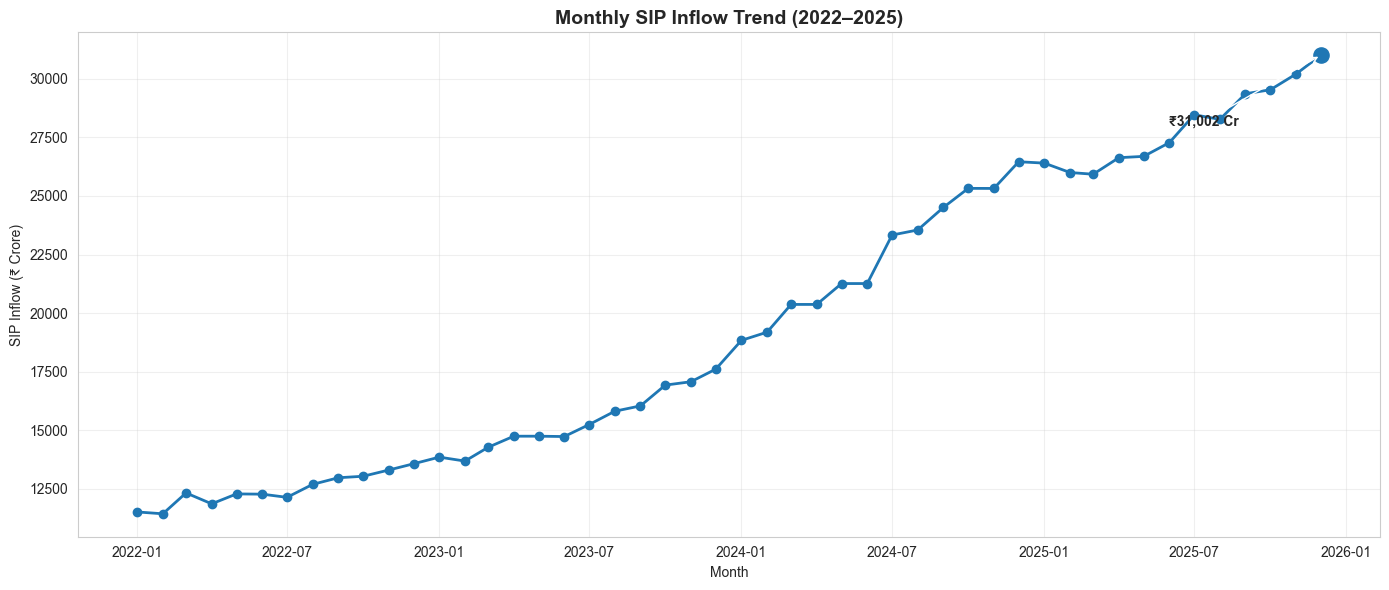

In [8]:
# Convert month column
sip_df["month"] = pd.to_datetime(sip_df["month"])

plt.figure(figsize=(14,6))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

# Highlight Dec 2025 milestone
plt.scatter(
    pd.Timestamp("2025-12-01"),
    31002,
    s=120
)

plt.annotate(
    "₹31,002 Cr",
    xy=(pd.Timestamp("2025-12-01"), 31002),
    xytext=(pd.Timestamp("2025-06-01"), 28000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    fontweight="bold"
)

plt.title(
    "Monthly SIP Inflow Trend (2022–2025)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_03_sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- SIP inflows increased consistently between January 2022 and December 2025, indicating strong growth in retail investor participation.
- Monthly SIP inflows grew from approximately ₹11,500 Cr in early 2022 to a record ₹31,002 Cr in December 2025.
- The trend shows a steady upward trajectory with no prolonged periods of decline.
- Growth accelerated during 2024 and 2025, reflecting increasing investor confidence in mutual funds as a long-term wealth creation vehicle.
- The record SIP inflow of ₹31,002 Cr in December 2025 highlights the expanding adoption of systematic investing among retail investors.
- Rising SIP contributions suggest a maturing investment culture and greater awareness of disciplined investing practices.

# Chart 4: Category-wise Inflow Heatmap

This heatmap visualizes net inflows across mutual fund categories over time.

Objective:
- Identify categories attracting the highest inflows
- Detect periods of strong investor preference
- Compare inflow patterns across categories
- Highlight sector rotation and investor sentiment trends

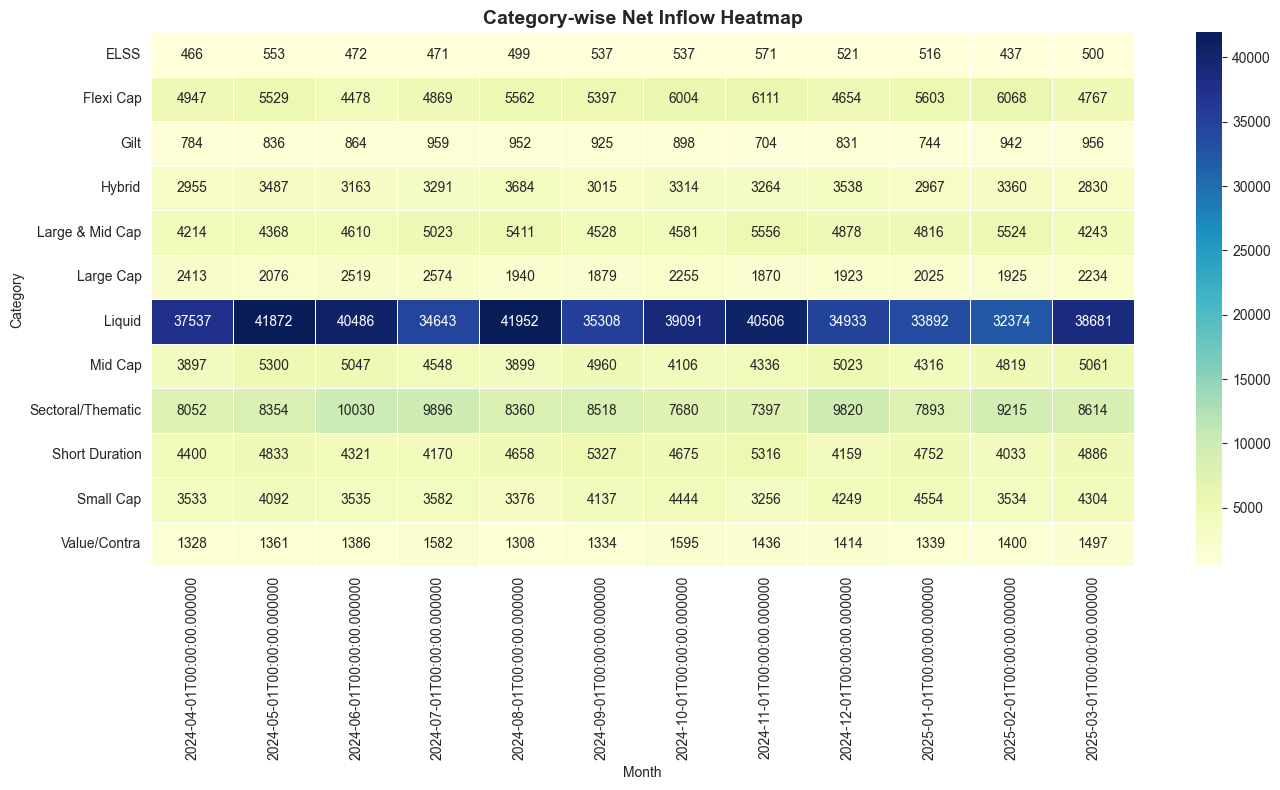

In [11]:
# Create copy
heatmap_df = category_df.copy()

# Convert month to datetime
heatmap_df["month"] = pd.to_datetime(
    heatmap_df["month"]
)

# Pivot table
heatmap_data = heatmap_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Net Inflow Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_04_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- Net inflows vary significantly across mutual fund categories.
- Equity-oriented categories generally attract higher inflows than conservative categories.
- Certain categories experience concentrated inflows during specific months, indicating changing investor preferences.
- Large Cap, Mid Cap and Small Cap categories consistently receive strong investor interest.
- Flexi Cap and Large & Mid Cap funds also show healthy inflow trends across the observed period.
- The heatmap clearly highlights periods of increased investor activity and category rotation.

# Chart 5A: Investor Age Group Distribution

This chart shows the distribution of investors across age groups.

Objective:
- Identify the dominant investor segment
- Understand mutual fund adoption across age categories
- Compare participation levels among investors

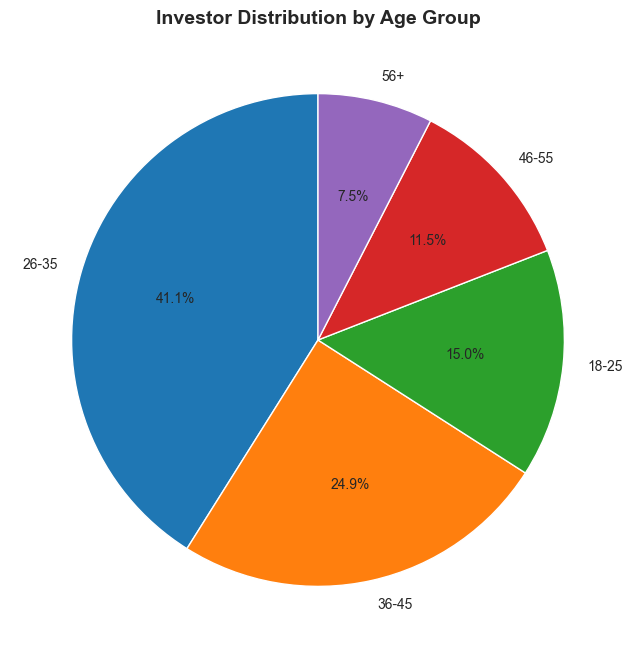

In [ ]:

age_counts = (
    transactions_df["age_group"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Distribution by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    "../reports/charts/chart_05A_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- Investors aged 26–35 form the largest investor segment.
- The 36–45 age group is the second-largest contributor.
- Younger investors (18–25) already represent a significant share of participation.
- Participation gradually declines after age 45.
- The data suggests mutual funds are most popular among working-age investors.

# Chart 5B: SIP Amount Distribution by Age Group

This box plot compares SIP investment amounts across age groups.

Objective:
- Understand investment behaviour across age categories
- Identify age groups contributing larger SIP amounts
- Detect outliers and investment variability

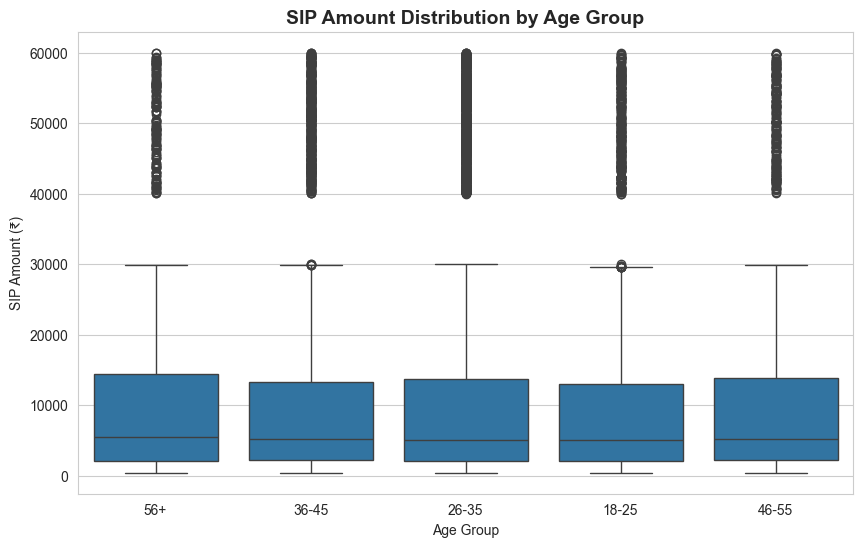

In [16]:
sip_age = transactions_df[
    transactions_df["transaction_type"] == "Sip"
].copy()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_age,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "../reports/charts/chart_05B_sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- SIP contribution amounts vary considerably across age groups.
- Middle-aged investors generally contribute higher SIP amounts.
- The 26–35 and 36–45 segments display the widest investment range.
- Several high-value SIP outliers are visible across age groups.
- Younger investors tend to invest smaller amounts but contribute significantly through volume.
- Investment behaviour becomes more diversified as investor age increases.

# Chart 6A: Geographic Distribution of SIP Investments

This chart shows total investment amount by state.

Objective:
- Identify states contributing the highest investment volumes
- Understand geographic distribution of mutual fund participation
- Highlight regions with stronger investor activity

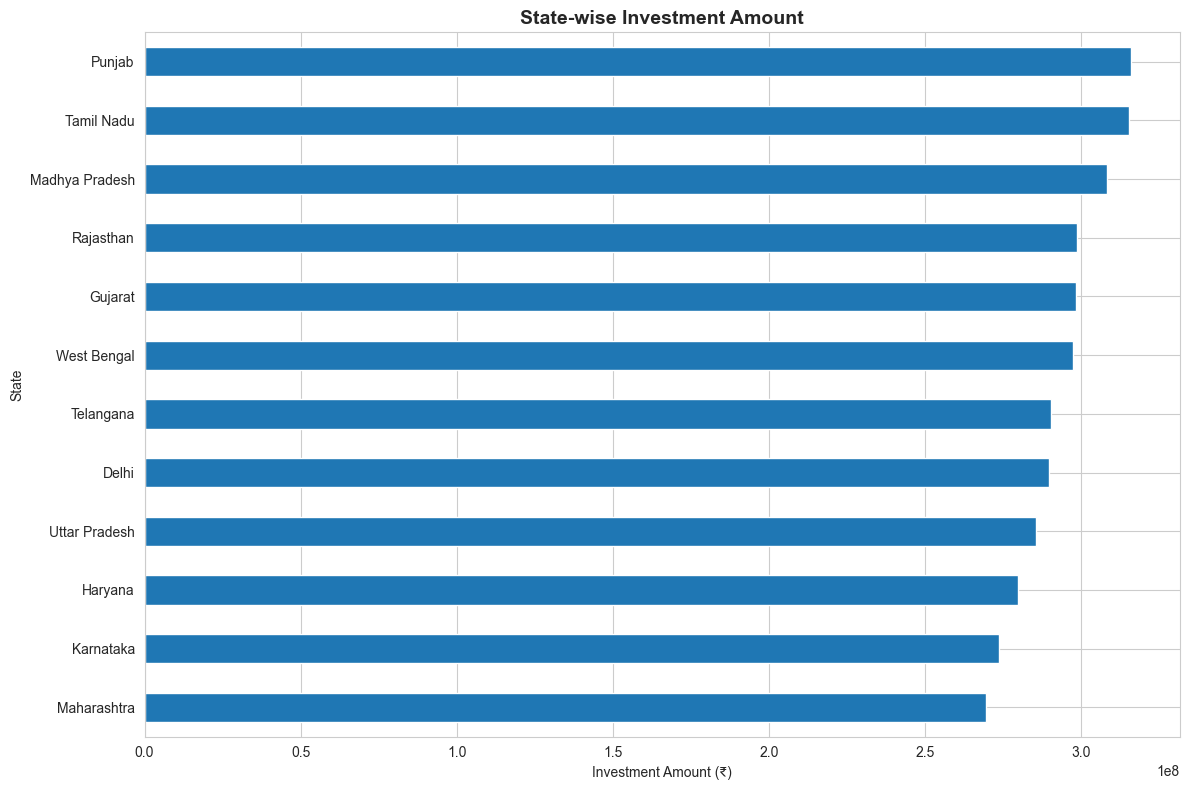

In [19]:

state_sip = (
    transactions_df
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.plot(
    kind="barh"
)

plt.gca().invert_yaxis()

plt.title(
    "State-wise Investment Amount",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_06A_state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- Investment activity is distributed across multiple states rather than concentrated in a single region.
- Punjab, Tamil Nadu and Madhya Pradesh emerge among the highest contributing states.
- Several northern and southern states demonstrate strong participation in mutual fund investments.
- Geographic diversification suggests widespread mutual fund adoption across India.
- State-level investment patterns can help identify high-engagement investor markets.

# Chart 6B: T30 vs B30 Investor Distribution

This chart compares investor participation between Top-30 (T30) cities and Beyond-30 (B30) cities.

Objective:
- Assess urban concentration of mutual fund participation
- Compare investor presence in developed and emerging markets
- Understand market penetration outside major cities

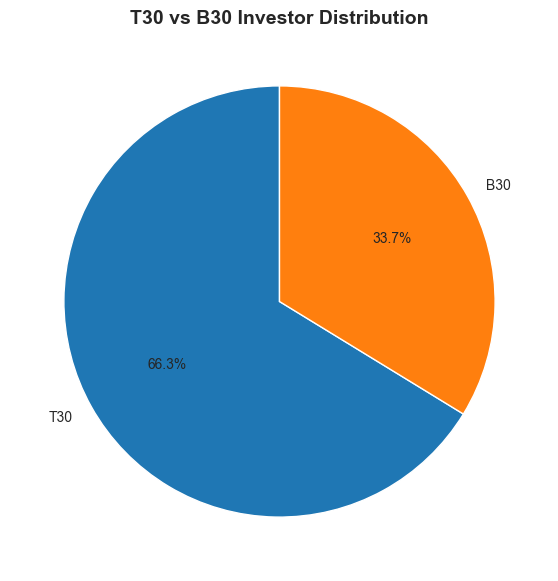

In [20]:
tier_counts = (
    transactions_df["city_tier"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 Investor Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    "../reports/charts/chart_06B_t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- T30 cities account for the majority of investor participation.
- B30 cities also contribute a meaningful share, indicating increasing mutual fund penetration beyond metropolitan regions.
- The gap between T30 and B30 participation highlights continued growth opportunities in smaller cities.
- Expanding financial awareness and digital investment platforms are likely supporting B30 market growth.
- The data suggests mutual funds are becoming increasingly accessible across India.

# Chart 7: Mutual Fund Folio Count Growth (2022–2025)

This chart tracks the growth in mutual fund folio counts from January 2022 to December 2025.

Objective:
- Measure growth in investor participation
- Highlight the increase in folio ownership
- Demonstrate expansion of the mutual fund industry

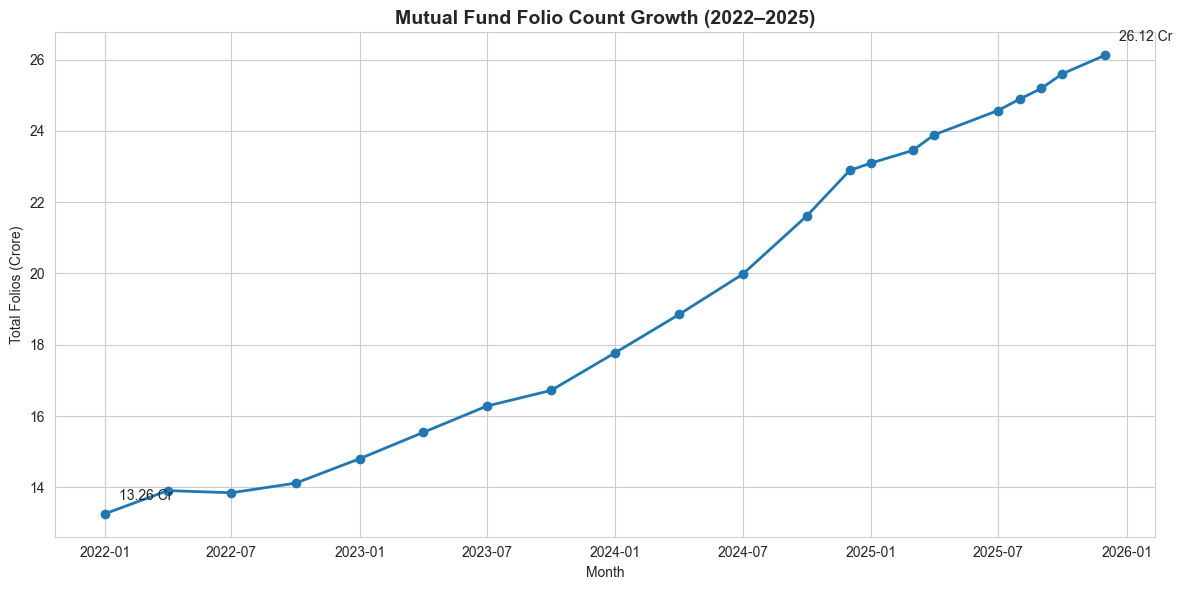

In [24]:

folio_chart = folio_df.copy()

folio_chart["month"] = pd.to_datetime(
    folio_chart["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio_chart["month"],
    folio_chart["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Starting milestone
plt.annotate(
    "13.26 Cr",
    xy=(
        folio_chart["month"].iloc[0],
        folio_chart["total_folios_crore"].iloc[0]
    ),
    xytext=(10,10),
    textcoords="offset points"
)

# Ending milestone
plt.annotate(
    "26.12 Cr",
    xy=(
        folio_chart["month"].iloc[-1],
        folio_chart["total_folios_crore"].iloc[-1]
    ),
    xytext=(10,10),
    textcoords="offset points"
)

plt.title(
    "Mutual Fund Folio Count Growth (2022–2025)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_07_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025.
- The folio count nearly doubled over the four-year period.
- Growth remained consistently positive with no major declines.
- Increasing folio counts indicate rising retail investor participation in mutual funds.
- The strongest growth was observed during 2024 and 2025.
- The trend reflects growing investor awareness and adoption of mutual fund products.

# Chart 8: Correlation Matrix of Fund Returns

This heatmap shows the pairwise correlation of daily NAV returns across 10 selected mutual fund schemes.

Objective:
- Identify funds that move together
- Understand diversification opportunities
- Detect highly correlated fund categories

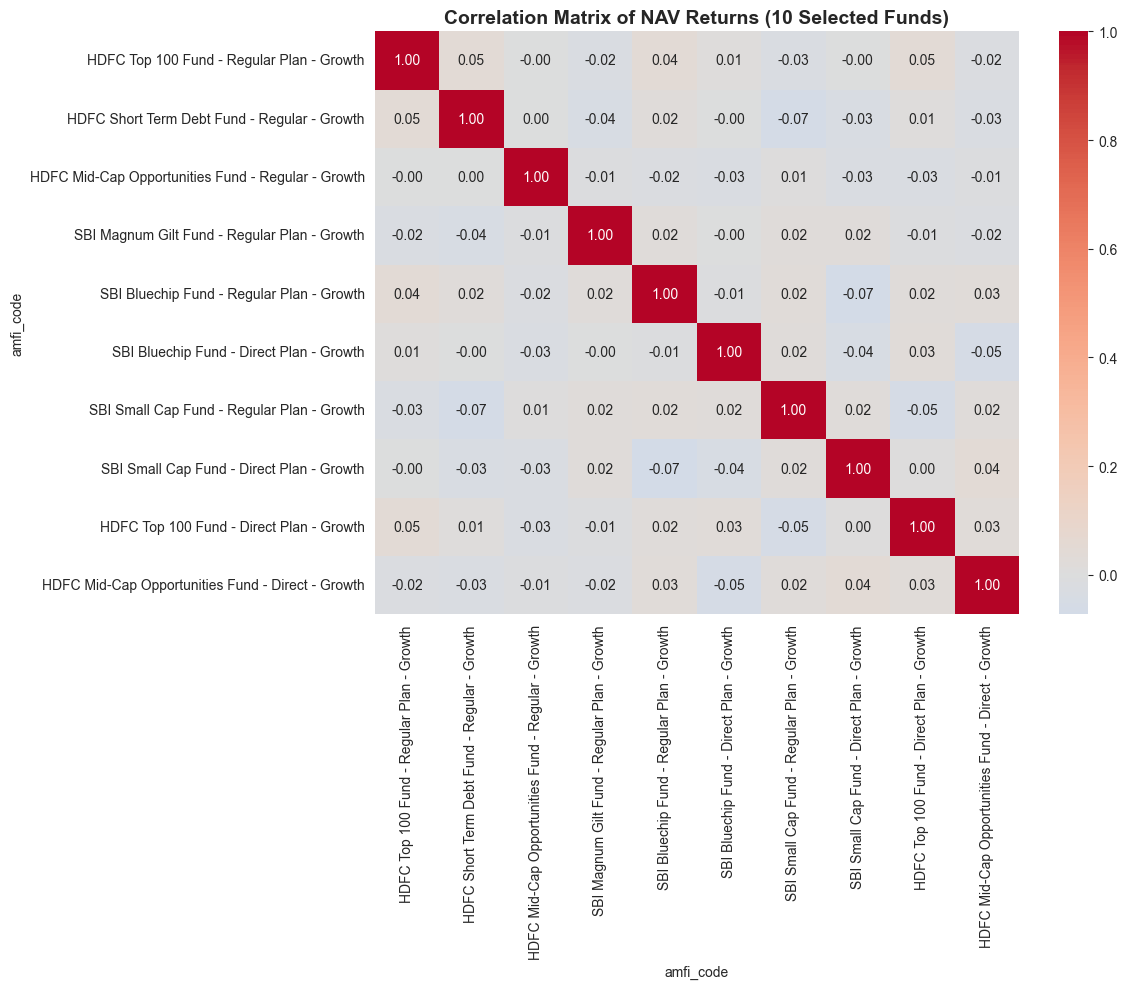

In [27]:


# Select first 10 funds
selected_funds = fund_df["amfi_code"].head(10).tolist()

# Filter NAV data
corr_nav = nav_df[
    nav_df["amfi_code"].isin(selected_funds)
].copy()

# Date conversion
corr_nav["date"] = pd.to_datetime(
    corr_nav["date"]
)

# Create NAV matrix
nav_matrix = corr_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns_matrix = nav_matrix.pct_change().dropna()

# Correlation matrix
corr_matrix = returns_matrix.corr()

# Rename columns using scheme names
fund_map = (
    fund_df
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

corr_matrix.rename(
    index=fund_map,
    columns=fund_map,
    inplace=True
)

# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of NAV Returns (10 Selected Funds)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_08_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- Most equity-oriented funds exhibit positive correlations, indicating similar market exposure.
- Direct and Regular plans of the same scheme show very high correlations.
- Debt-oriented schemes generally display lower correlations with equity schemes.
- Highly correlated funds provide limited diversification benefits.
- Lower correlation values indicate better diversification opportunities for investors.
- The correlation matrix helps identify fund combinations that can reduce portfolio risk.

# Chart 9: Sector Allocation Across Mutual Fund Portfolios

This donut chart visualizes sector-wise portfolio allocation across all mutual fund holdings.

Objective:
- Identify sectors receiving the highest portfolio allocation
- Understand fund manager sector preferences
- Analyze concentration across industries

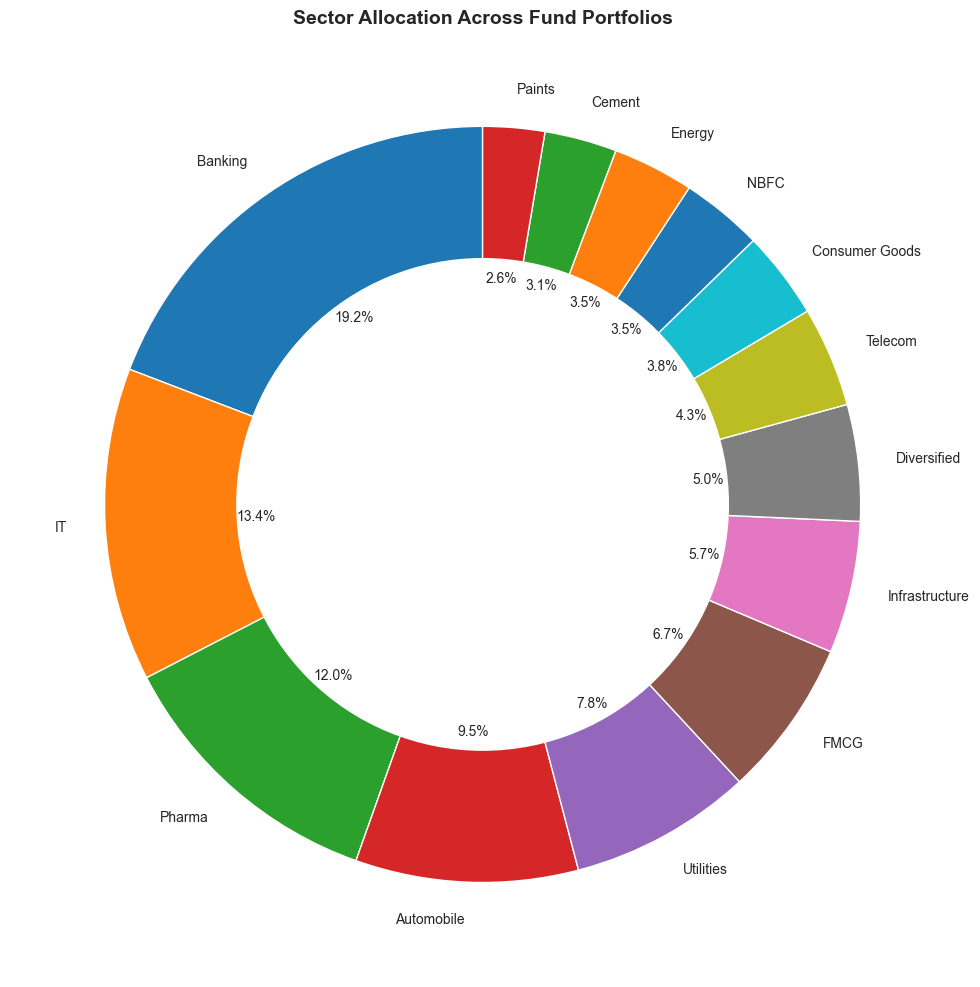

In [31]:

sector_weights = (
    portfolio_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90
)

# Donut hole
centre_circle = plt.Circle(
    (0, 0),
    0.65,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Fund Portfolios",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/chart_09_sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings

- Banking represents the largest sector allocation across mutual fund portfolios.
- IT and Pharma also account for significant portfolio weights.
- Fund managers show a preference for established sectors with strong market capitalization.
- Sector allocation is diversified across multiple industries, reducing concentration risk.
- Defensive sectors such as FMCG, Utilities and Pharma maintain meaningful portfolio representation.
- Financial services continue to dominate portfolio construction strategies.

# Key EDA Findings Summary

## 1. Strong NAV Growth Across Schemes
All 40 mutual fund schemes demonstrated long-term NAV appreciation between 2022 and 2026, reflecting sustained growth in the Indian mutual fund industry.

## 2. Significant Growth in Assets Under Management (AUM)
SBI Mutual Fund emerged as the industry leader, reaching approximately ₹12.5 lakh crore AUM by the end of 2025, significantly ahead of other fund houses.

## 3. SIP Inflows Reached Record Levels
Monthly SIP inflows increased steadily from around ₹11,500 crore in early 2022 to a record ₹31,002 crore in December 2025, indicating growing retail investor participation.

## 4. Equity Categories Attracted Strongest Inflows
Large Cap, Mid Cap, Small Cap and Flexi Cap categories consistently recorded strong inflows, highlighting investor preference for equity-oriented investments.

## 5. Young and Middle-Aged Investors Dominate Participation
The 26–35 age group represented the largest investor segment, followed by the 36–45 age group, showing that working-age individuals drive mutual fund adoption.

## 6. SIP Investments Are Widely Distributed Across Age Groups
Box plot analysis revealed similar median SIP contribution levels across age groups, although several high-value investment outliers were observed.

## 7. Mutual Fund Participation Is Expanding Geographically
Investment activity was distributed across multiple states, demonstrating widespread adoption of mutual funds beyond traditional financial centers.

## 8. T30 Cities Continue To Lead Investor Participation
Top-30 cities accounted for the majority of investors, although B30 cities contributed a substantial share, indicating increasing penetration into emerging markets.

## 9. Mutual Fund Folios Nearly Doubled
Total folio count increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting rapid growth in investor participation.

## 10. Banking Remains The Dominant Portfolio Sector
Sector allocation analysis showed that Banking, IT and Pharma collectively account for a significant share of portfolio weights, reflecting fund managers' preference for established sectors.

## 11. High Correlation Exists Among Similar Fund Categories
Correlation analysis revealed strong positive relationships among funds with similar investment mandates, while debt-oriented funds exhibited lower correlation with equity funds.

## 12. Industry Growth Is Driven By Retail Investors
The combined rise in SIP inflows, folio counts and AUM indicates that retail investors continue to be the primary growth engine of the mutual fund industry.